# Text Mining Project — Market Sentiment Classification
**Spring Semester 2025/2026 | NOVA IMS**

Classifying financial tweets into three sentiment categories:
- **0 — Bearish** (negative / pessimistic)
- **1 — Bullish** (positive / optimistic)
- **2 — Neutral**

---
<a class='anchor' id='toc'></a>
## Table of Contents

1. [Setup & Imports](#1)
2. [Data Exploration](#2)
   - [2.1 Dataset Overview & Structure](#2-1)
     - Dataset Overview
     - Duplicates
     - Class Distribution
   - [2.2 Textual Content Analysis](#2-2)
     - Tweet Length Analysis
     - Vocabulary Analysis and Word Clouds
     - Financial Sentiment Words
     - Exclusive Words By Sentiment Class
     - Lexical Dispersion
   - [2.3 N-gram and Token Analysis](#2-3)
     - N-gram Analysis by Class
     - Hashtags and Cashtags Analysis
   - [2.4 Tweet-Specific Features & Signals](#2-4)
     - Presence of Tweet-Specific Features
     - Uppercase Analysis
     - Mention Analysis
     - Hashtag Deep-Dive
     - Emoji Analysis
     - Special Characters
   - [2.5 Key Findings](#2-5)
3. [Data Preprocessing](#3)
   - [3.1 Step-by-step Demonstration](#3-1)
   - [3.2 Lemmatization vs Stemming](#3-2)
   - [3.3 Preprocessing Functions](#3-3)
   - [3.4 Apply to Full Training Set](#3-4)
   - [3.5 Before / After Comparison](#3-5)
   - [3.6 Vocabulary Impact](#3-6)
   - [3.7 Tweets with Little Content After Cleaning](#3-7)
4. [Corpus Split — Stratified K-Fold](#4)
5. [Feature Engineering](#5)
   - [5.1 BoW & TF-IDF](#5-1)
   - [5.2 Word2Vec](#5-2)
   - [5.3 Transformer Encoder Embeddings](#5-3)
6. [Classification Models](#6)
   - [6.1 Evaluation Helper](#6-1)
   - [6.2 Traditional ML — TF-IDF Pipeline](#6-2)
   - [6.3 Traditional ML — Word2Vec Pipeline](#6-3)
   - [6.4 Transformer Encoder + Classifier Head](#6-4)
   - [6.5 Fine-tuned FinBERT (End-to-end)](#6-5)
7. [Evaluation & Analysis](#7)
8. [Final Predictions on test.csv](#8)

<a class='anchor' id='1'></a>
---
## 1. Setup & Imports

In [1]:
!pip install nltk gensim xgboost wordsegment -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter, defaultdict
from itertools import combinations
import re, string, warnings
from scipy import stats
warnings.filterwarnings('ignore')
from wordcloud import WordCloud

import nltk
for pkg in ['stopwords','punkt','punkt_tab','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.util import ngrams
from tqdm import tqdm

STOP = set(stopwords.words('english'))
lemma        = WordNetLemmatizer()
stemmer      = SnowballStemmer('english')
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

[↑ Back to TOC](#toc)

<a class='anchor' id='2'></a>
---

# **2. Data Exploration**

Before jumping into preprocessing and modelling, we start by getting to know the data. This chapter walks through the key properties of the training set, from its basic structure and class balance to the vocabulary, linguistic patterns, and tweet-specific elements that may shape our preprocessing and modelling decisions.

<a class='anchor' id='2-1'></a>

## **2.1 Dataset Overview and Structure**

We begin with a first look at the dataset itself. Here we examine its shape, spot any duplicate entries, and check how the three sentiment classes are distributed

### **Dataset Overview** 

This first step provides a general overview of the dataset, including its dimensions, variables, data types, missing values, and initial observations.

In [3]:
df = pd.read_csv('train.csv')
# Print the dimensions of the DataFrame (rows, columns)
print(f'Shape: {df.shape}')

# Print the list of column names
print(f'Columns: {list(df.columns)}')

# Print the data type of each column
print(f'Types:\n{df.dtypes}')

# Print the count of missing (NaN) values per column
print(f'\nMissing values:\n{df.isnull().sum()}')

# Display the first 10 rows of the DataFrame
df.head(10)

Shape: (9543, 2)
Columns: ['text', 'label']
Types:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


### **Duplicate Analysis**

This step checks whether the training dataset contains duplicated tweets or tweets that appear multiple times with different sentiment labels.

In [4]:
# Count rows with duplicate text (regardless of label)
exact_duplicates = df.duplicated(subset='text').sum()
# Count rows with duplicate text AND label
label_duplicates = df.duplicated(subset=['text', 'label']).sum()

print(f'Duplicate tweets (same text): {exact_duplicates}')
print(f'Duplicate tweets (same text + label): {label_duplicates}')

# Show duplicate examples if any exist
if exact_duplicates > 0:
    mask = df.duplicated(subset='text', keep=False)
    print(f'\nDuplicate tweet examples:')
    print(df[mask][['text','label']].sort_values('text').head(10).to_string())
    
    # Edge case: same tweet with conflicting labels — dangerous for training!
    conflicts = df[mask].groupby('text')['label'].nunique()
    conflicts = conflicts[conflicts > 1]  # Keep only texts with more than one distinct label
    print(f'\nTweets with conflicting labels (same text, different label): {len(conflicts)}')
    if len(conflicts) > 0:
        # Show the conflicting rows
        print(df[df['text'].isin(conflicts.index)][['text','label']].sort_values('text').head(10).to_string())

Duplicate tweets (same text): 0
Duplicate tweets (same text + label): 0


**Dataset Overview and Duplicate Analysis - Conclusions:**

- **Dataset structure:**  
  The training dataset contains 9543 tweets and 2 columns: `text` and `label`. The `text` column contains the tweet content, while the `label` column contains the sentiment class assigned to each tweet.

- **Data types:**  
  The data types are appropriate for this classification task. The `text` column is stored as an object/string variable, and the `label` column is stored as an integer, which is suitable for representing the sentiment classes.

- **Missing values:**  
  No missing values were found in either column. This means that no tweets need to be removed or imputed due to missing text or labels.

- **Duplicate records:**  
  No duplicated tweets were found in the dataset. There were also no duplicated rows with the same text and label. Therefore, there is no evidence of repeated tweets or conflicting duplicated labels in the training data.

  Overall, the dataset is clean and structurally suitable for the next stages of the project. The main variables are available, the data types are correct, and no missing or duplicated records were detected.

### **Class Distribution**

This analysis examines the distribution of the three sentiment classes and helps identify possible class imbalance in the dataset. 

Class count
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


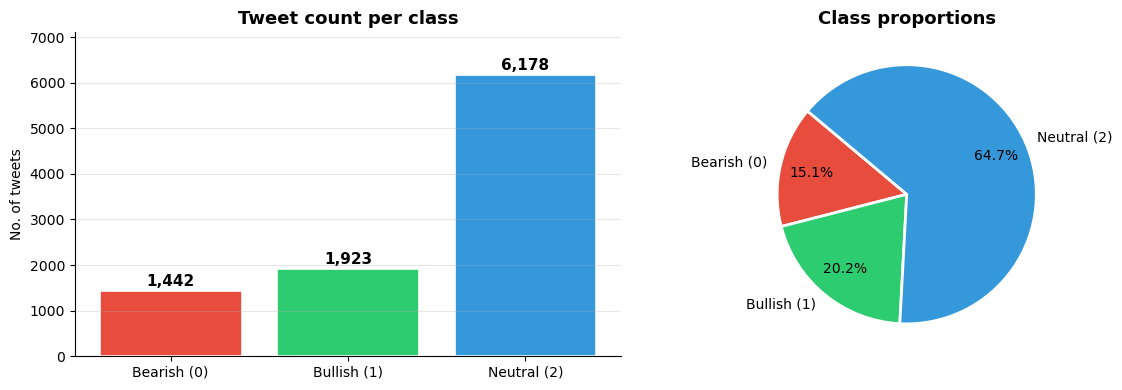


Baseline (majority class): 64.7% — any model should beat this value.


In [5]:
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('Class count')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — count per class with value labels on top
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Tweet count per class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No. of tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart — class proportions
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Majority class baseline: accuracy of a model that always predicts the most frequent class.
# Any trained model must beat this, otherwise it has learned nothing useful.
majority_acc = label_counts.max() / len(df) * 100
print(f'\nBaseline (majority class): {majority_acc:.1f}% — any model should beat this value.')

**Class Distribution - Conclusions:**

- **Imbalanced dataset:**  
  The class distribution shows a clear imbalance in the training data. Neutral tweets represent the majority class, with 6178 tweets (64.7%), while Bullish tweets account for 1923 tweets (20.2%) and Bearish tweets for only 1442 tweets (15.1%).

- **Majority class baseline:**  
  Since the Neutral class represents 64.7% of the dataset, a simple model that always predicts Neutral would already achieve 64.7% accuracy. Therefore, accuracy alone may be misleading, as it could hide poor performance on the minority classes.

- **Impact on model evaluation and metric choice:**  
  Because Bearish and Bullish tweets are less represented, models may become biased toward the Neutral class if the imbalance is not considered. For this reason, Macro F1-score will be used as an important evaluation metric in the modelling stage. Unlike accuracy, Macro F1-score gives equal importance to each class, making it more appropriate for evaluating performance in an imbalanced multi-class classification problem.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-2'></a>

## **2.2 Textual Content Analysis**

With the dataset structure understood, we now dive into the actual content of the tweets. Here we explore the words and expressions that characterise each sentiment class, looking at everything from tweet length and the most frequent terms to the lexical patterns that may carry predictive signal.

### **Tweet Length Analysis**

We start by looking at how long tweets tend to be across each sentiment class, both in terms of word and character count, to understand whether length itself could be an informative feature.

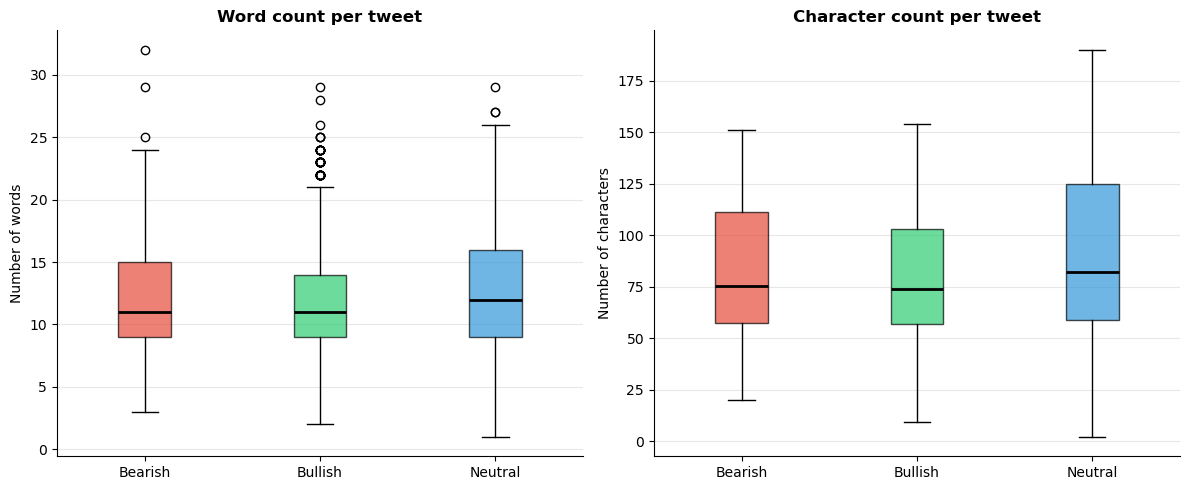

Kruskal-Wallis p-value for word count: 0.0113
Kruskal-Wallis p-value for character count: 0.0000000000000014

Average length per class:
             n_words  n_chars
label                        
Bearish (0)     12.0     83.4
Bullish (1)     11.9     80.4
Neutral (2)     12.3     88.1


In [6]:
# Compute length features for each tweet
df["n_words"] = df["text"].str.split().str.len()
df["n_chars"] = df["text"].str.len()

# Boxplots by sentiment class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for metric, ax, title, ylabel in [
    ("n_words", axes[0], "Word count per tweet", "Number of words"),
    ("n_chars", axes[1], "Character count per tweet", "Number of characters")
]:
    data = [
        df[df["label"] == lbl][metric].values
        for lbl in [0, 1, 2]
    ]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 2}
    )

    for patch, lbl in zip(bp["boxes"], [0, 1, 2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)

    ax.set_xticklabels(["Bearish", "Bullish", "Neutral"], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Kruskal-Wallis tests for length differences across classes
word_groups = [
    df[df["label"] == lbl]["n_words"]
    for lbl in [0, 1, 2]
]

char_groups = [
    df[df["label"] == lbl]["n_chars"]
    for lbl in [0, 1, 2]
]

stat_words, p_words = stats.kruskal(*word_groups)
stat_chars, p_chars = stats.kruskal(*char_groups)

print(f"Kruskal-Wallis p-value for word count: {p_words:.4f}")
print(f"Kruskal-Wallis p-value for character count: {p_chars:.16f}")

# Average length by class
print("\nAverage length per class:")
print(
    df.groupby("label")[["n_words", "n_chars"]]
    .mean()
    .round(1)
    .rename(index=CLASS_NAMES)
)

**Tweet Length Analysis - Conclusions:**

- The boxplots show that tweet length is generally similar across the three sentiment classes. However, Neutral tweets appear slightly longer, especially in terms of character count, and also show a wider range of values.

- Some outliers are present in all classes, particularly in the word count distribution. These correspond to tweets that are longer than most observations in the same class, which is expected in social media data where tweet length can vary considerably.

- To complement the visual analysis, the Kruskal-Wallis test was applied. This non-parametric test evaluates whether the distributions of tweet length are statistically different across the three sentiment classes.

- The hypotheses tested are:
  - H₀: Bearish, Bullish, and Neutral tweets have the same length distribution.
  - H₁: At least one sentiment class has a different length distribution.

- The test results show statistically significant differences for both word count and character count. This supports what is suggested by the boxplots: the classes are not exactly identical in terms of tweet length.

- The difference is stronger for character count, where the p-value is extremely small. This is consistent with the class averages, since Neutral tweets have the highest average number of characters, followed by Bearish and then Bullish tweets.

- However, the average word counts are very close across classes: Bearish tweets have 12.0 words on average, Bullish tweets have 11.9, and Neutral tweets have 12.3. Therefore, although the Kruskal-Wallis test detects statistically significant differences, the practical difference in word count is small.

<a class='anchor' id='2-11'></a>
### **Stopword Analysis**

NLTK's default stopword list was built for general English. In financial tweets, some 
of these words carry strong directional or negation signal and should not be removed. 
We first identify which stopwords are most frequently present in our corpus, then 
selectively restore the ones with financial relevance before any preprocessing is applied.

In [7]:
# Which stopwords appear most often in financial tweets? 
removed_stopwords = Counter()

for text in tqdm(df['text'].tolist(), desc='Counting stopwords'):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text)
    text = re.sub(r'[^a-zA-Z\s?+%&!$-]', ' ', text)
    tokens = word_tokenize(text)
    for w in tokens:
        if w in STOP:
            removed_stopwords[w] += 1

print(f'Total unique stopwords found: {len(removed_stopwords)}')
print(f'\n{"Word":<15} {"Count":>8}')
print('-' * 25)
for word, count in removed_stopwords.most_common(40):
    print(f'{word:<15} {count:>8,}')

Counting stopwords: 100%|██████████| 9543/9543 [00:00<00:00, 11516.38it/s]

Total unique stopwords found: 139

Word               Count
-------------------------
to                 2,652
the                2,559
s                  2,259
of                 1,676
in                 1,617
a                  1,411
on                 1,367
for                1,220
and                1,029
is                   868
at                   664
as                   608
with                 501
after                490
up                   484
by                   469
from                 430
more                 418
are                  409
this                 366
it                   331
its                  288
will                 258
that                 256
here                 252
what                 251
be                   238
has                  235
you                  228
have                 226
t                    223
down                 206
over                 198
about                193
but                  181
or                   179
how           

**Stopword Analysis — Conclusion:**

The following stopwords appear frequently but carry financial meaning and will be 
restored before preprocessing:

- **Directional**: *up, down, above, below, over, under, off* 
- **Negations**: *not, no* 
- **Degree**: *more, most, too, further, few* 

In [8]:
# Restore financially relevant stopwords before any preprocessing
financial_keep_words = [
    'up', 'down', 'above', 'below', 'over', 'under', 'off',
    'not', 'no',
    'more', 'most', 'too', 'further', 'few'
]

restored = [w for w in financial_keep_words if w in STOP]
for word in restored:
    STOP.remove(word)

print(f'Restored {len(restored)} words from STOP set: {", ".join(restored)}')
print(f'STOP set size: {len(STOP) + len(restored)} → {len(STOP)}')


Restored 14 words from STOP set: up, down, above, below, over, under, off, not, no, more, most, too, further, few
STOP set size: 198 → 184


### **Vocabulary Analysis and Word Clouds**

We take a visual and quantitative look at the most frequent words across and within each class. Tweets were lightly cleaned beforehand, removing URLs, mentions, hashtags, punctuation, and stopwords, to make the most informative terms more visible. Since classes may differ in size, frequencies are presented per 1000 words to allow a fairer comparison across Bearish, Bullish, and Neutral tweets.

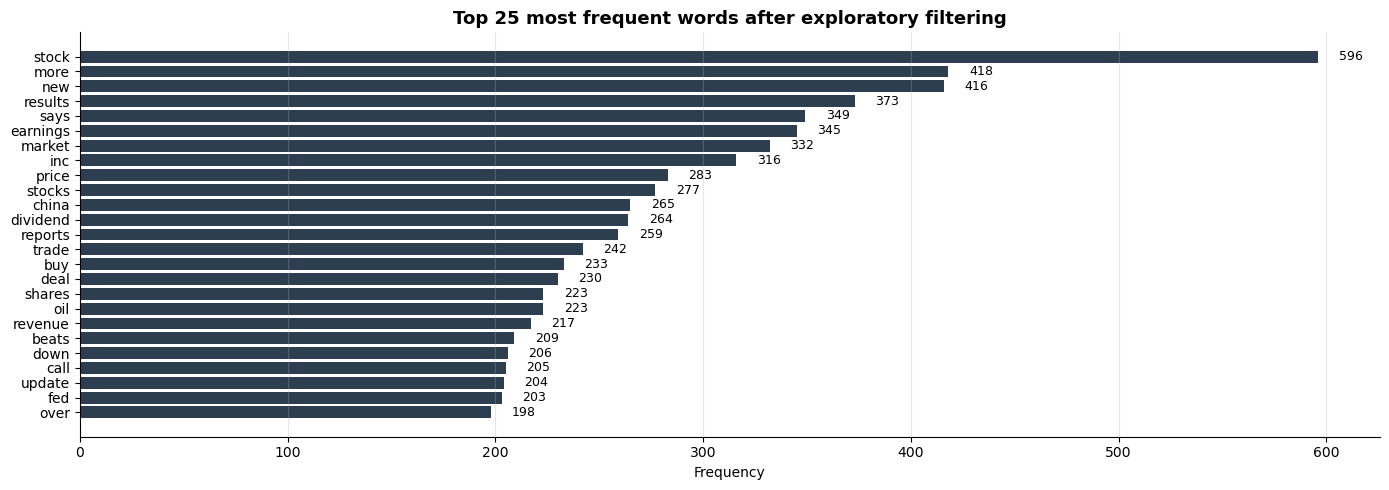

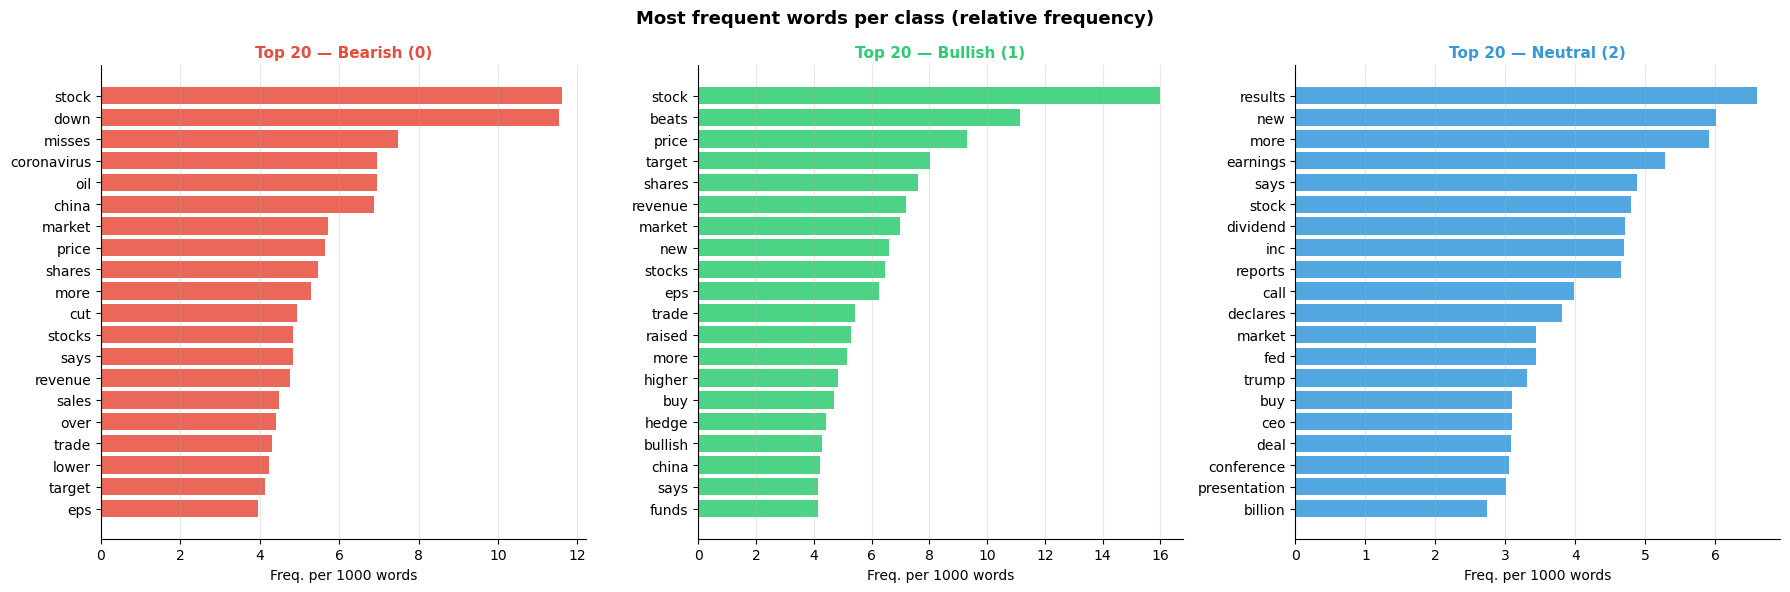

In [9]:
# tokenize_clean: strip URLs, mentions, hashtags, punctuation and stopwords

def tokenize_clean(text):
    """Tokenizes, lowercases, removes punctuation, URLs, mentions, hashtags and stopwords."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)            # remove @mentions and #hashtags
    text = re.sub(r'[^a-zA-Z\s?+%&!$-]', ' ', text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

# Overall vocabulary 

# Build a flat list of all tokens across every tweet
all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_clean(txt))

# Calculate word frequencies
vocab  = set(all_tokens)
freq  = Counter(all_tokens)
top50 = freq.most_common(50)

# Horizontal bar chart — top 25 most frequent words
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')

# Add frequency labels at the end of each bar
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', fontsize=9)

ax.set_title('Top 25 most frequent words after exploratory filtering',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


# Most frequent words by sentiment class 

# Build a token counter for each sentiment class
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_clean(txt))
    tokens_per_class[lbl] = Counter(toks)

# Total token count per class (used to normalise frequencies)
total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Relative frequency per 1000 words (only words appearing at least 5 times)
    rel_freq = {w: cnt / total_per_class[lbl] * 1000
                for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]

    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. per 1000 words')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Most frequent words per class (relative frequency)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

We also generated word clouds for each sentiment class to provide a visual complement to the previous vocabulary analysis.

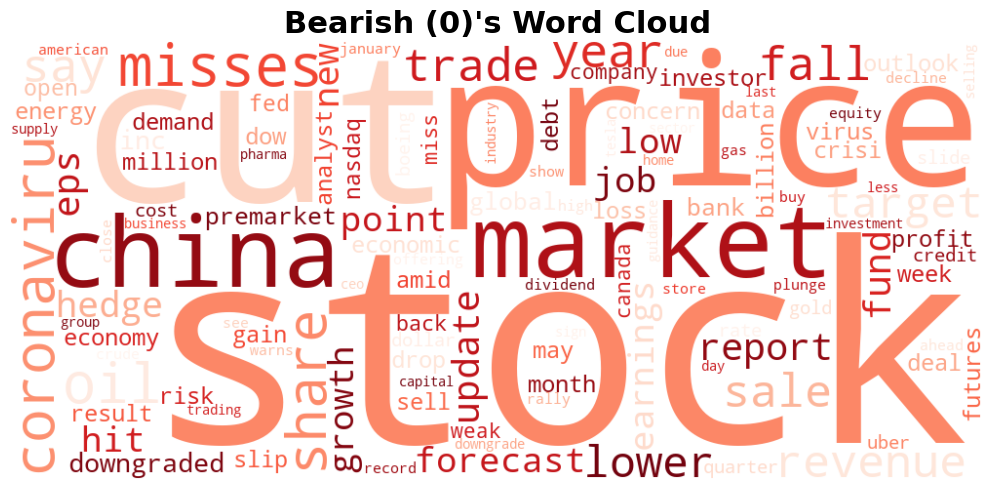

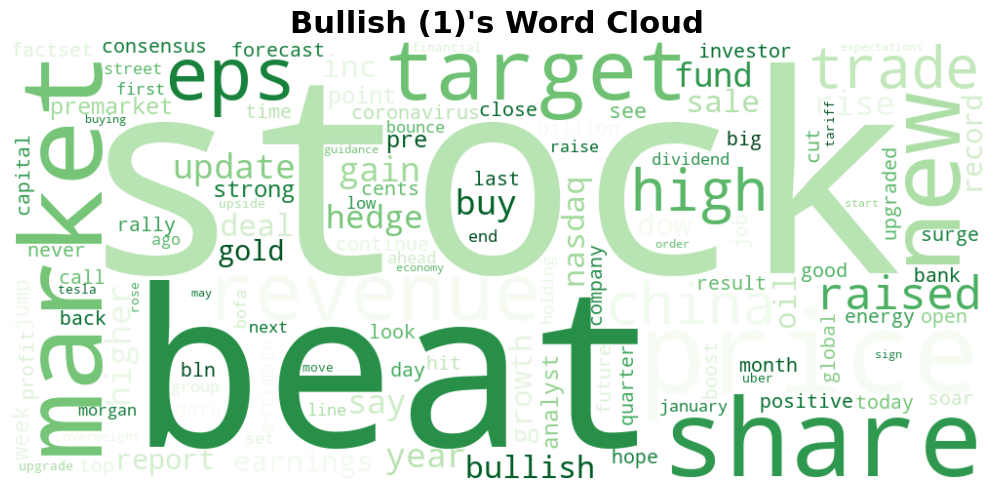

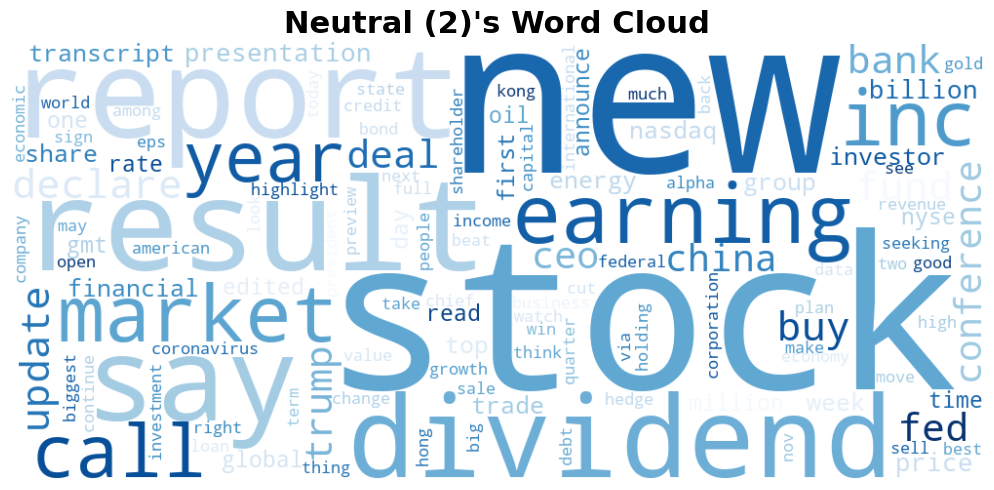

In [10]:
# Create one large word cloud per class
for lbl in [0, 1, 2]:
    class_tokens = []
    
    for txt in df[df["label"] == lbl]["text"]:
        class_tokens.extend(tokenize_clean(txt))
    
    text_for_cloud = " ".join(class_tokens)
    
    wordcloud = WordCloud(
        width=1000,
        height=450,
        background_color="white",
        colormap="Greens" if lbl == 1 else "Reds" if lbl == 0 else "Blues",
        collocations=False,
        max_words=120
    ).generate(text_for_cloud)
    
    plt.figure(figsize=(12, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"{CLASS_NAMES[lbl]}'s Word Cloud", fontsize=22, fontweight="bold")
    plt.tight_layout()
    plt.show()

**Vocabulary Analysis and Word Clouds - Conclusion:**

- **Common financial vocabulary:**  
  The vocabulary analysis shows that all three sentiment classes share a common financial lexicon, with frequent terms such as *stock*, *market*, *price*, *earnings*, and *trade*. This confirms that the dataset is strongly centered on financial and market-related topics.

- **Bearish vocabulary patterns:**  
  Bearish tweets contain more negative or downward-oriented terms, such as *misses*, *cut*, *lower*, and *revenue*. These words are consistent with weaker company performance, negative expectations, or downward market movements.

- **Bullish vocabulary patterns:**  
  Bullish tweets are more associated with positive performance and analyst-related language, including terms such as *beats*, *target*, *raised*, *higher*, and *bullish*. This suggests that Bullish tweets often refer to positive expectations, upgrades, or better-than-expected results.

- **Neutral vocabulary patterns:**  
  Neutral tweets are dominated by factual and reporting-oriented words, such as *results*, *earnings*, *dividend*, *reports*, *declares*, *call*, and *conference*. This suggests that Neutral tweets often contain financial information without expressing a clear positive or negative market direction.

- **Implications for modelling:**  
  Overall, these results suggest that vocabulary patterns contain useful sentiment information. This supports the use of text-based feature extraction methods in the modelling stage, since relevant sentiment cues appear across the lexical patterns of each class.

### **Financial Sentiment Words**

Here we zoom in on domain-specific vocabulary. We handpicked a list of financial terms commonly associated with positive and negative market sentiment, and examine whether these words appear more prominently in one class than another.

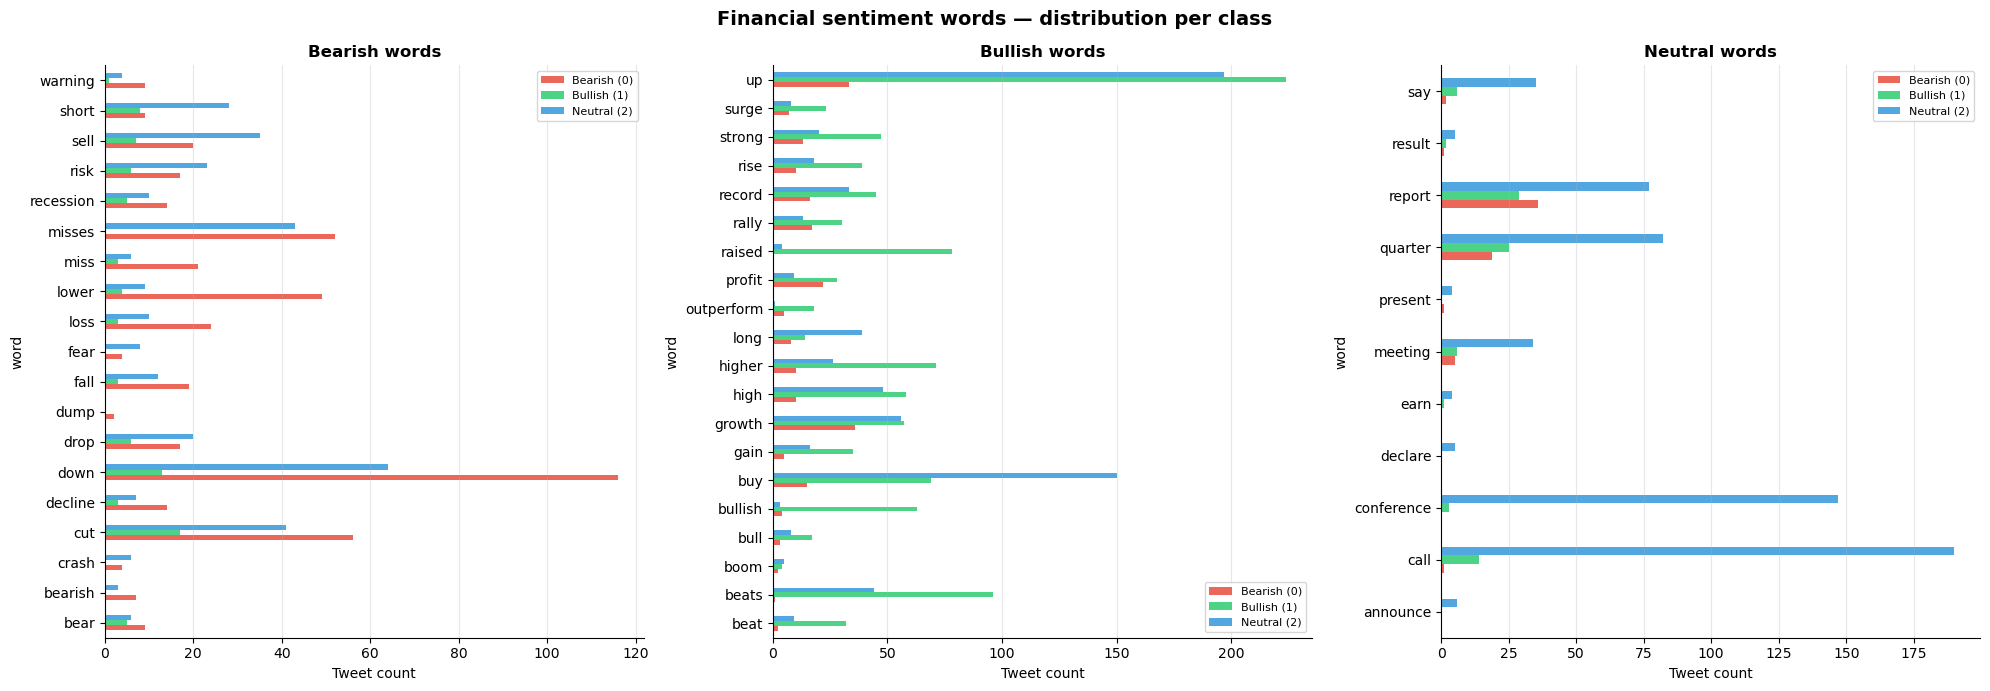

In [11]:
financial_words = {
    'Bearish': ['bear','bearish','crash','dump','fall','drop','loss',
                'decline','miss','misses','cut','lower','down','sell',
                'short','recession','fear','risk','warning'],
    'Bullish': ['bull','bullish','rally','rise','gain','surge','high',
                'beat','beats','raised','higher','buy','long','growth',
                'profit','record','boom','up','strong','outperform'],
    'Neutral': ['report','result','earn','announce','declare','say',
                'conference','meeting','call','present','quarter']
}

results = []
for category, words in financial_words.items():
    for word in words:
        for lbl in [0,1,2]:
            count = df[df['label']==lbl]['text'].str.lower().str.contains(
                rf'\b{word}\b', regex=True).sum()
            results.append({'category':category,'word':word,
                            'class':CLASS_NAMES[lbl],'count':count})
res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (category, color) in zip(axes, [('Bearish','#e74c3c'),('Bullish','#2ecc71'),('Neutral','#3498db')]):
    cat_df = res_df[res_df['category']==category]
    pivot  = cat_df.pivot(index='word', columns='class', values='count').fillna(0)
    pivot.plot(kind='barh', ax=ax, color=[CLASS_COLORS[0],CLASS_COLORS[1],CLASS_COLORS[2]],
               edgecolor='none', alpha=0.85)
    ax.set_title(f'{category} words', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tweet count'); ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False); ax.legend(fontsize=8)
plt.suptitle('Financial sentiment words — distribution per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Financial Sentiment Words - Conclusions:**

- **Manual sentiment keywords provide a useful sanity check:**  
  This analysis uses manually selected financial sentiment words to check whether the dataset contains vocabulary patterns that are consistent with the assigned sentiment labels.

- **Bearish words show expected patterns:**  
  Several bearish-related words, such as *down*, *cut*, *lower*, *misses*, and *loss*, appear more frequently in Bearish tweets. This supports the idea that class 0 captures negative or downward market sentiment.

- **Bullish words are strongly associated with positive market language:**  
  Words such as *beats*, *raised*, *higher*, *up*, *surge*, and *bullish* appear frequently in Bullish tweets, suggesting that class 1 is associated with positive performance, upgrades, or upward market movement.

- **Neutral words reflect informational content:**  
  Neutral-related words such as *call*, *conference*, *quarter*, *report*, and *result* appear more often in Neutral tweets. This is consistent with Neutral tweets being more focused on reporting financial information rather than expressing a clear positive or negative direction.

- **Interpretation caution:**  
  Since the word groups were manually defined, this analysis should be interpreted as exploratory rather than definitive. Some words may appear across multiple sentiment classes depending on context.

- **Overall assessment:**  
  Overall, the results suggest that the dataset is coherent, since many manually selected sentiment-related terms appear more often in the expected classes. This supports the use of lexical features such as Bag of Words and TF-IDF in the modelling stage.

### **Exclusive Words By Sentiment Class**

We then look at words that appear exclusively in one sentiment class, helping identify the most distinctive terms that could serve as strong classification signals.

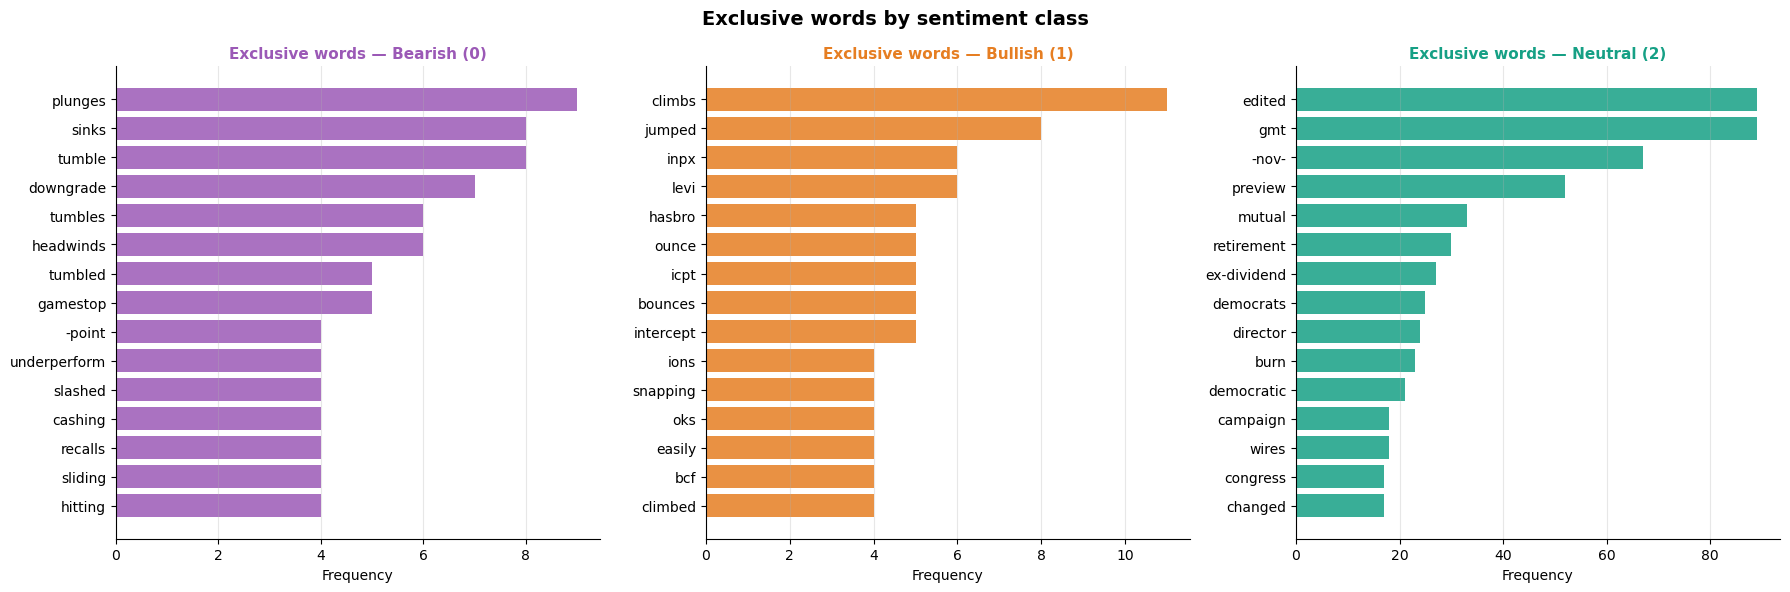

In [12]:
# Build vocabulary and word frequency counters for each sentiment class
vocab_per_class = {}
freq_per_class = {}

for lbl in [0, 1, 2]:
    class_tokens = []
    
    for text in df[df["label"] == lbl]["text"]:
        class_tokens.extend(tokenize_clean(text))
    
    vocab_per_class[lbl] = set(class_tokens)
    freq_per_class[lbl] = Counter(class_tokens)

# Alternative color palette for this visualization
EXCLUSIVE_COLORS = {
    0: "#9b59b6",  # Purple
    1: "#e67e22",  # Orange
    2: "#16a085"   # Teal
}

# Plot the top exclusive words for each class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Words that appear in the current class but not in the other classes
    other_classes_vocab = set().union(
        *[vocab_per_class[other_lbl] for other_lbl in [0, 1, 2] if other_lbl != lbl]
    )
    
    exclusive_words = vocab_per_class[lbl] - other_classes_vocab
    
    # Select the most frequent exclusive words
    top_exclusive_words = sorted(
        exclusive_words,
        key=lambda word: freq_per_class[lbl][word],
        reverse=True
    )[:15]
    
    counts = [freq_per_class[lbl][word] for word in top_exclusive_words]
    
    ax.barh(
        list(reversed(top_exclusive_words)),
        list(reversed(counts)),
        color=EXCLUSIVE_COLORS[lbl],
        edgecolor="none",
        alpha=0.85
    )
    
    ax.set_title(
        f"Exclusive words — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=EXCLUSIVE_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Exclusive words by sentiment class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Exclusive Words by Sentiment Class - Conclusion:**

The chart shows that some words appear exclusively within a single sentiment class. However, several of these words have relatively low frequencies, especially in the Bearish and Bullish classes, so they should be interpreted carefully. Overall, this analysis suggests that there are some class-specific vocabulary patterns.

### **Lexical Dispersion**

Finally, we examine how key terms are distributed across the corpus, giving a sense of how consistently certain words appear throughout the dataset.

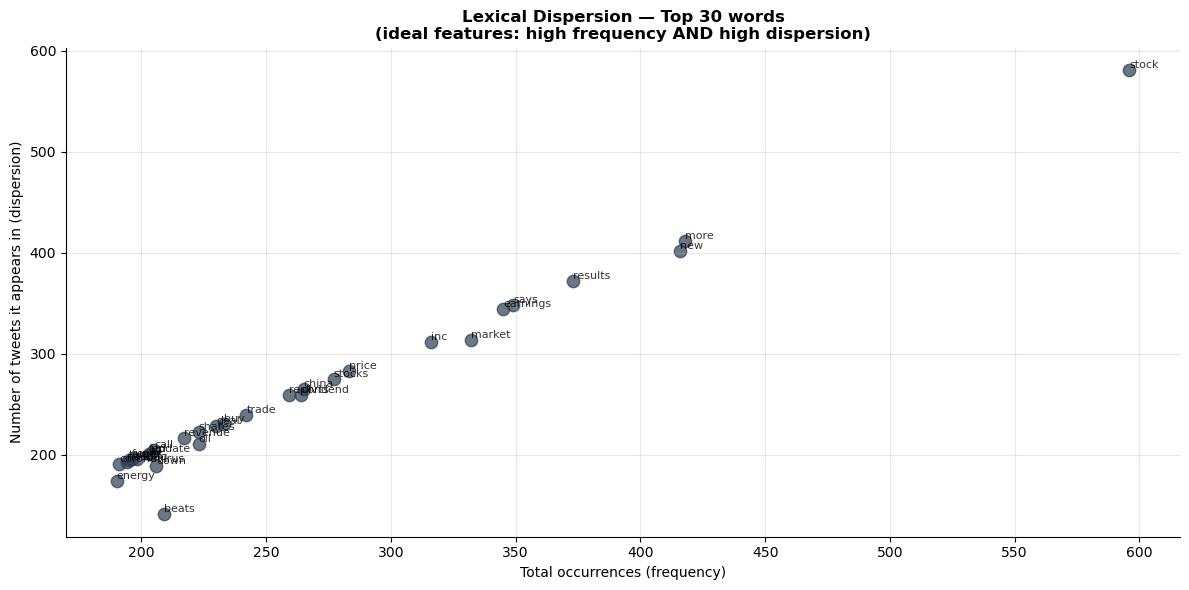

CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.


In [13]:
word_doc_count = defaultdict(int)
word_total     = Counter()

for text in df['text']:
    tokens_set = set(tokenize_clean(text))
    for t in tokens_set:
        word_doc_count[t] += 1

for text in df['text']:
    word_total.update(tokenize_clean(text))

top30 = [w for w, _ in word_total.most_common(30)]
x_vals = [word_total[w]    for w in top30]
y_vals = [word_doc_count[w] for w in top30]

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(x_vals, y_vals, c='#2c3e50', alpha=0.7, s=80)
for i, word in enumerate(top30):
    ax.annotate(word, (x_vals[i], y_vals[i]),
                fontsize=8, ha='left', va='bottom', alpha=0.8)
ax.set_xlabel('Total occurrences (frequency)')
ax.set_ylabel('Number of tweets it appears in (dispersion)')
ax.set_title('Lexical Dispersion — Top 30 words\n(ideal features: high frequency AND high dispersion)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()
print('CONCLUSION: Words concentrated in few tweets → set min_df=2 or min_df=3 in TF-IDF/BoW.')

**Lexical Dispersion — Conclusion:**

- **Frequent words are also widely dispersed:**  
  The scatter plot shows that most of the top frequent words also appear across many different tweets. This means that these terms are not concentrated in only a few repeated tweets, but are spread throughout the corpus.

- **Strong financial vocabulary:**  
  Words such as *stock*, *new*, *results*, *earnings*, *market*, and *price* have both high frequency and high dispersion. This confirms that they are central terms in the financial tweet corpus.

- **Useful for feature extraction:**  
  Words with both high frequency and high dispersion are useful for text-based feature extraction methods, because they represent recurring vocabulary patterns across the dataset.

- **Need for filtering rare terms:**  
  Some words may appear frequently enough to be detected but still have lower dispersion, meaning they are concentrated in fewer tweets. This supports the use of filtering strategies such as `min_df` in Bag of Words or TF-IDF, to reduce the impact of very rare or overly specific terms.

- **Overall assessment:**  
  Overall, the analysis supports the use of BoW and TF-IDF representations, while also suggesting that very rare terms should be filtered to reduce noise and improve generalization.

A word that appears 500 times but only in 3 tweets is not a good feature (likely noise). This justifies the min_df parameter in TF-IDF.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-3'></a>
## **2.3 N-gram and Token Analysis**

Moving beyond individual words, we look at multi-word patterns and token-level signals that may characterise each sentiment class. This section covers both n-gram sequences and the specific hashtags and cashtags that appear across the corpus.

### **N-gram Analysis by Class**

Here we analyse the most frequent bigrams and trigrams within each sentiment class, capturing common multi-word expressions and phrases that single-word analysis would miss.

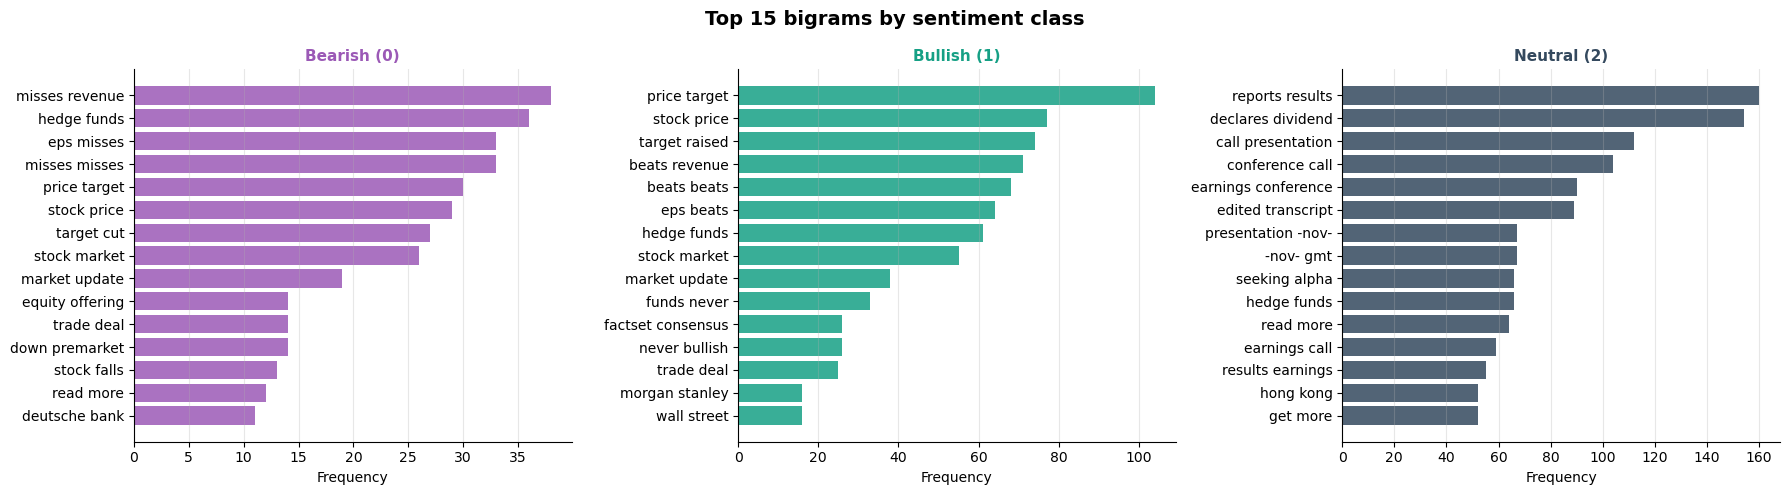

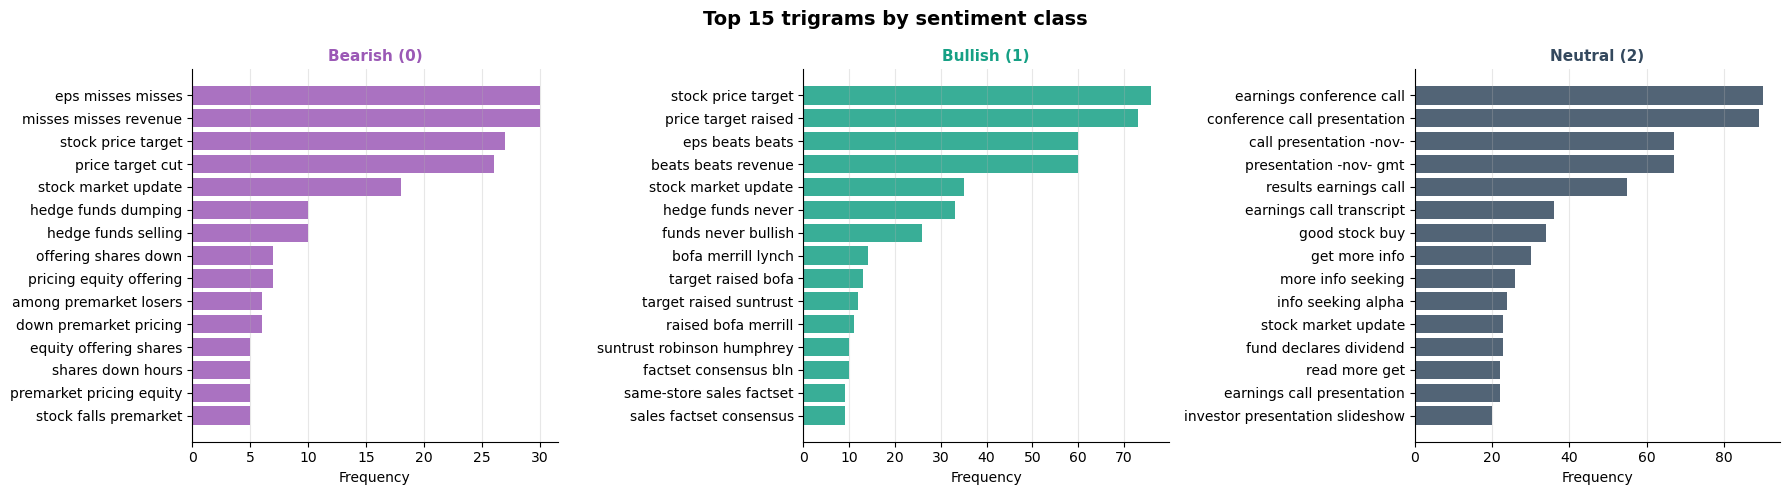

In [14]:
def get_ngrams(texts, n=2):
    """Extract n-grams from a collection of texts using the exploratory cleaning function."""
    all_ngrams = []
    
    for text in texts:
        tokens = tokenize_clean(text)
        all_ngrams.extend([" ".join(group) for group in ngrams(tokens, n)])
    
    return Counter(all_ngrams)


# Alternative color palette for the n-gram visualizations
NGRAM_COLORS = {
    0: "#9b59b6",  # Purple
    1: "#16a085",  # Teal
    2: "#34495e"   # Dark blue-gray
}

# Plot the top 15 bigrams and trigrams for each sentiment class
for n, ngram_name in [(2, "bigrams"), (3, "trigrams")]:
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for lbl, ax in zip([0, 1, 2], axes):
        ngrams_counter = get_ngrams(df[df["label"] == lbl]["text"], n=n)
        top_ngrams = ngrams_counter.most_common(15)
        
        if top_ngrams:
            words, counts = zip(*top_ngrams)
            
            ax.barh(
                list(reversed(words)),
                list(reversed(counts)),
                color=NGRAM_COLORS[lbl],
                edgecolor="none",
                alpha=0.85
            )
        
        ax.set_title(
            CLASS_NAMES[lbl],
            fontsize=11,
            fontweight="bold",
            color=NGRAM_COLORS[lbl]
        )
        
        ax.set_xlabel("Frequency")
        ax.grid(axis="x", alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    
    plt.suptitle(f"Top 15 {ngram_name} by sentiment class", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

**N-gram Analysis by Class - Conclusion:**

The n-gram analysis shows that short word combinations capture relevant financial and market-related patterns across the three sentiment classes. In the Bearish class, expressions such as “misses revenue”, “eps misses”, “target cut”, “stock falls”, and “eps misses misses” are associated with negative company performance or downward market movements. In the Bullish class, expressions such as “price target”, “target raised”, “beats revenue”, “eps beats”, and “price target raised” reflect positive expectations, analyst upgrades, or better-than-expected results.

Neutral tweets are more associated with reporting and corporate-event expressions, such as “reports results”, “declares dividend”, “conference call”, “earnings conference call”, and “call presentation nov”. These expressions are useful because they show that the Neutral class is often characterized by factual or event-based language, rather than directional market sentiment.

Overall, the comparison between bigrams and trigrams suggests that bigrams provide a good balance between context and generalization. While trigrams add more detail, some of them are more specific or repetitive, which may increase sparsity. Therefore, these results support testing TF-IDF with `ngram_range=(1,2)` in the feature engineering stage, as it captures useful short expressions without making the feature space too sparse.

### **Hashtags and Cashtags Analysis**

We then look at the most frequent hashtags and cashtags per class, examining whether certain topics or stock tickers are more associated with a particular sentiment.

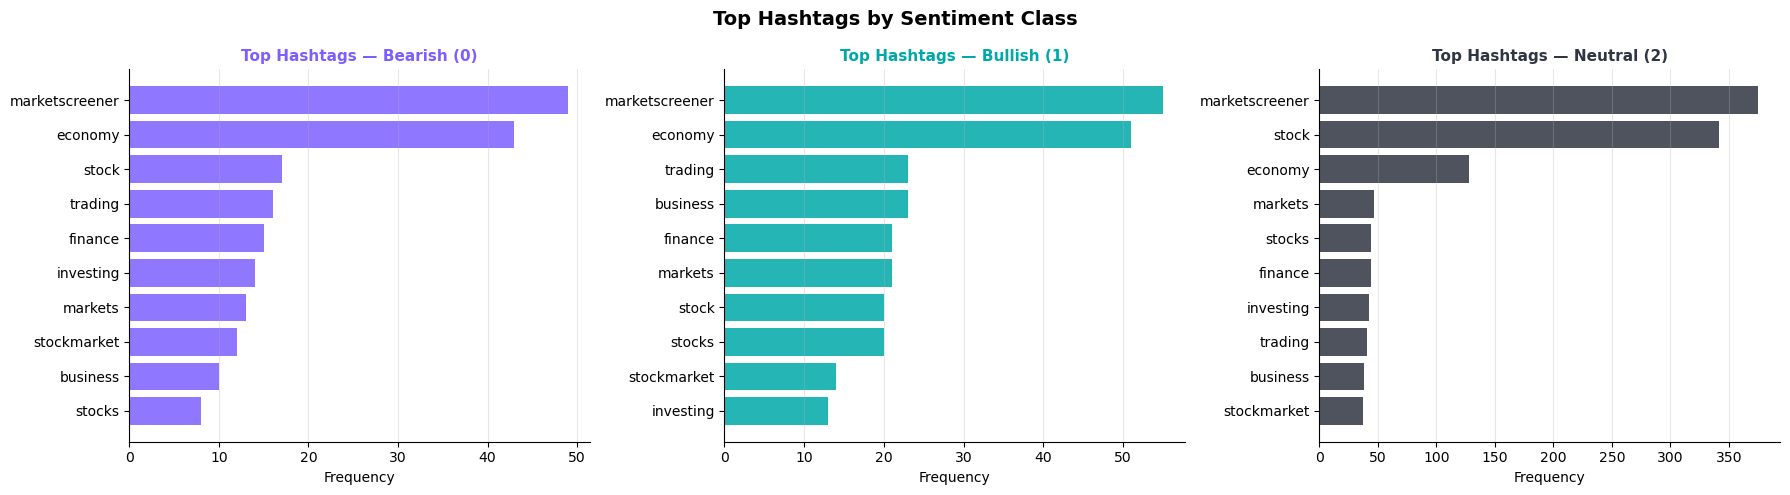

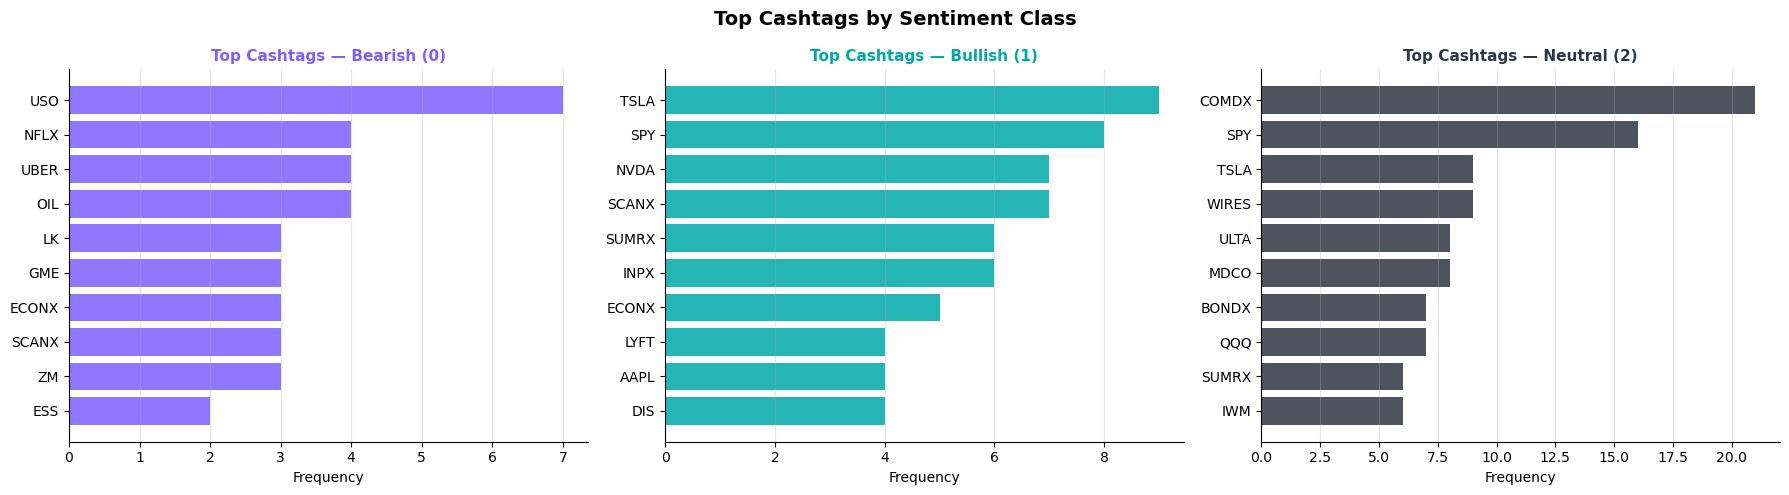

In [15]:
# Alternative color palette for class-based hashtag and cashtag visualizations
TOKEN_COLORS = {
    0: "#7d5fff",  # Violet
    1: "#00a8a8",  # Teal
    2: "#2f3542"   # Charcoal
}


# Plot top hashtags by sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lbl, ax in zip([0, 1, 2], axes):
    hashtags_class = []
    
    for txt in df[df["label"] == lbl]["text"]:
        hashtags_class.extend(re.findall(r"#(\w+)", str(txt).lower()))
    
    top_hashtags_class = Counter(hashtags_class).most_common(10)
    
    if top_hashtags_class:
        words, counts = zip(*top_hashtags_class)
        
        ax.barh(
            list(reversed(words)),
            list(reversed(counts)),
            color=TOKEN_COLORS[lbl],
            edgecolor="none",
            alpha=0.85
        )
    
    ax.set_title(
        f"Top Hashtags — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=TOKEN_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top Hashtags by Sentiment Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# Plot top cashtags by sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for lbl, ax in zip([0, 1, 2], axes):
    cashtags_class = []
    
    for txt in df[df["label"] == lbl]["text"]:
        cashtags_class.extend(re.findall(r"\$([A-Za-z]{1,5})", str(txt).upper()))
    
    top_cashtags_class = Counter(cashtags_class).most_common(10)
    
    if top_cashtags_class:
        words, counts = zip(*top_cashtags_class)
        
        ax.barh(
            list(reversed(words)),
            list(reversed(counts)),
            color=TOKEN_COLORS[lbl],
            edgecolor="none",
            alpha=0.85
        )
    
    ax.set_title(
        f"Top Cashtags — {CLASS_NAMES[lbl]}",
        fontsize=11,
        fontweight="bold",
        color=TOKEN_COLORS[lbl]
    )
    
    ax.set_xlabel("Frequency")
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Top Cashtags by Sentiment Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Hashtags and Cashtags Analysis - Conclusion:**

The hashtag analysis shows that the most frequent hashtags are very similar across the three sentiment classes, mainly representing broad financial topics such as markets, stocks, economy, and trading. Since they do not clearly distinguish sentiment classes, we decided to remove hashtags during preprocessing to reduce noise.

Cashtags, on the other hand, indicate that a financial asset or company is being mentioned. However, the sentiment associated with a specific ticker may depend on the time period of the tweet. For example, the same company could be associated with positive sentiment in one market period and negative sentiment in another. Since the temporal context of the tweets is not available, we decided to replace cashtags with a common placeholder token (`ticker`). This preserves the information that a financial asset was mentioned while reducing the risk of the model learning time-specific associations with individual companies or stock symbols.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-4'></a>
## **2.4 Tweet-Specific Features and Signals**

Beyond the words themselves, tweets carry a range of structural and stylistic elements that may also influence sentiment. Here we look at features like hashtags, mentions, emojis, and special characters, examining whether their presence and distribution differ across classes and whether they should be preserved, normalised, or removed during preprocessing.

### **Presence of Tweet-Specific Features**

We start with a broad overview, checking how often hashtags, mentions, URLs, numbers, and cashtags appear across each sentiment class, to get a sense of which elements are worth investigating further.

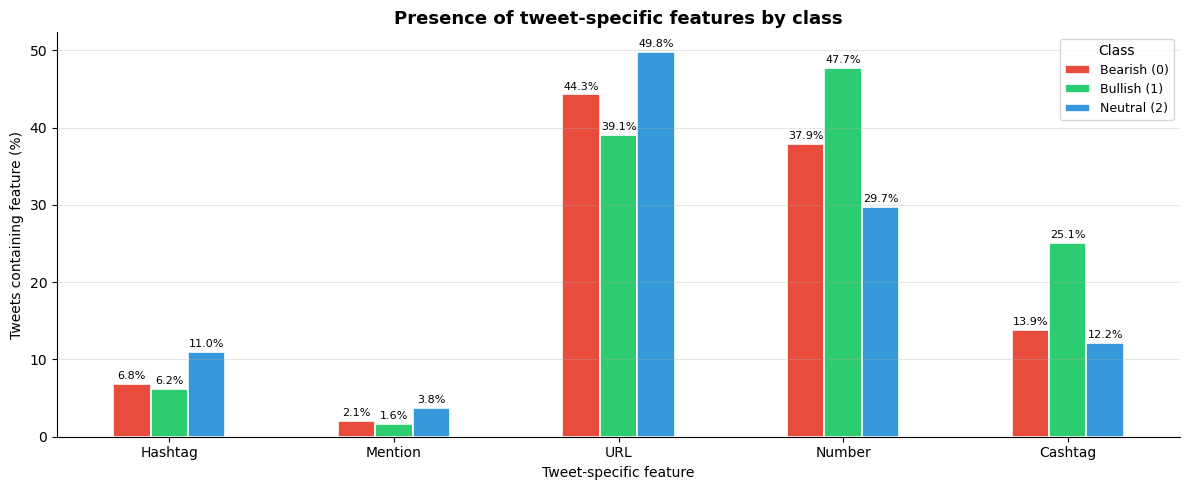

In [16]:
# ── Tweet-specific features: hashtags, mentions, URLs, numbers, cashtags ──────

# Count special elements in each tweet
df["n_hashtags"] = df["text"].apply(lambda x: len(re.findall(r"#\w+", str(x))))
df["n_mentions"] = df["text"].apply(lambda x: len(re.findall(r"@\w+", str(x))))
df["n_urls"] = df["text"].apply(lambda x: len(re.findall(r"http\S+|www\S+", str(x))))
df["n_numbers"] = df["text"].apply(lambda x: len(re.findall(r"\b\d+\.?\d*%?\b", str(x))))
df["has_cashtag"] = df["text"].apply(lambda x: bool(re.search(r"\$[A-Za-z]{1,5}", str(x))))

# Convert counts into binary presence indicators
df["has_hashtag"] = df["n_hashtags"] > 0
df["has_mention"] = df["n_mentions"] > 0
df["has_url"] = df["n_urls"] > 0
df["has_number"] = df["n_numbers"] > 0

presence_features = [
    "has_hashtag",
    "has_mention",
    "has_url",
    "has_number",
    "has_cashtag"
]

presence_labels = [
    "Hashtag",
    "Mention",
    "URL",
    "Number",
    "Cashtag"
]

# Calculate percentage of tweets containing each feature by class
presence_by_class = (
    df.groupby("label")[presence_features]
    .mean()
    .T * 100
)

presence_by_class.columns = [CLASS_NAMES[i] for i in presence_by_class.columns]
presence_by_class.index = presence_labels

# Plot grouped bar chart
ax = presence_by_class.plot(
    kind="bar",
    figsize=(12, 5),
    color=[CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]],
    edgecolor="white",
    linewidth=1.2
)

ax.set_title("Presence of tweet-specific features by class", fontsize=13, fontweight="bold")
ax.set_xlabel("Tweet-specific feature")
ax.set_ylabel("Tweets containing feature (%)")
ax.set_xticklabels(presence_labels, rotation=0)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Class", fontsize=9)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8,
        padding=2
    )

plt.tight_layout()
plt.show()

**Presence of Tweet-Specific Features - Conclusions**

- **URLs are the most common structural feature:**  
  URLs appear frequently across all sentiment classes, especially in Neutral tweets (49.9%), followed by Bearish tweets (44.3%) and Bullish tweets (39.1%). This suggests that links are a common element in financial tweets, often used to share news, reports, or external sources.

- **Numbers are also frequent, especially in Bullish tweets:**  
  Numeric expressions appear in 47.7% of Bullish tweets, 37.9% of Bearish tweets, and 29.8% of Neutral tweets. This may reflect the frequent use of prices, percentages, targets, earnings values, or other financial indicators in market-related tweets.

- **Cashtags are relevant in this corpus:**  
  Cashtags appear in 25.1% of Bullish tweets, 13.9% of Bearish tweets, and 12.2% of Neutral tweets. Since cashtags refer directly to financial assets or companies, they may contain useful information. However, instead of keeping the original symbols, they will be replaced with a common placeholder token (`ticker`) during preprocessing.

- **Hashtags and mentions are less frequent:**  
  Hashtags appear in a small proportion of tweets across all classes, ranging from 6.2% to 11.0%. Mentions are even less common, appearing in less than 4% of tweets in every class. This suggests that mentions are unlikely to be strong predictors of sentiment, while hashtags require further inspection to decide whether they contain useful class-specific information.

- **Overall assessment:**  
  This analysis helps guide preprocessing decisions. URLs and mentions can be removed because they mainly represent structural noise. Cashtags should be normalized into the placeholder token `ticker`, while hashtags and numbers should be handled carefully depending on whether they provide useful sentiment or financial information.

### **Uppercase Analysis**

Here we look at whether Bearish tweets tend to use more capitalised words, since ALL CAPS is often used for emphasis in financial contexts. This helps us decide whether lowercasing would discard a potentially useful signal.

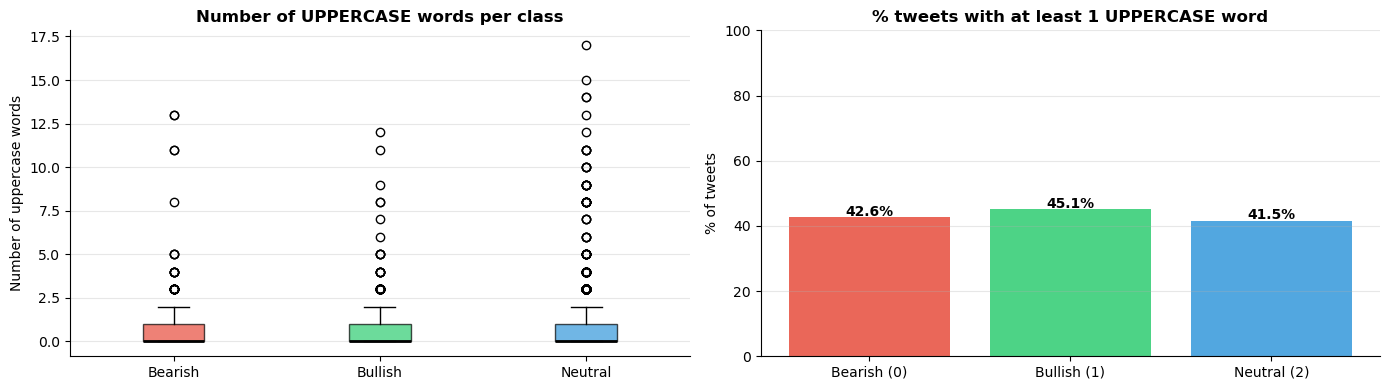

Kruskal-Wallis test: statistic=4.52  p-value=0.1042
→ No significant difference. We can safely apply lowercase without losing relevant information.


In [17]:
# Uppercase analysis per class
df_caps = pd.read_csv('train.csv')

# Remove cashtags first so tickers ($TSLA) don't inflate the caps count
df_caps['text_no_cashtag'] = df_caps['text'].str.replace(r'\$[A-Za-z]{1,5}', ' ', regex=True)

df_caps['n_caps_words'] = df_caps['text_no_cashtag'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)
df_caps['n_caps_chars'] = df_caps['text_no_cashtag'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)
df_caps['pct_caps_words'] = df_caps.apply(
    lambda row: row['n_caps_words'] / max(len(str(row['text_no_cashtag']).split()), 1) * 100,
    axis=1
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot — Number of UPPERCASE words per class
data_caps = [df_caps[df_caps['label'] == lbl]['n_caps_words'].values for lbl in [0, 1, 2]]
bp = axes[0].boxplot(data_caps, patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
for patch, lbl in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(CLASS_COLORS[lbl])
    patch.set_alpha(0.7)
axes[0].set_xticklabels(['Bearish', 'Bullish', 'Neutral'])
axes[0].set_title('Number of UPPERCASE words per class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of uppercase words')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# % of tweets with at least 1 uppercase word
pct_with_caps = df_caps.groupby('label').apply(
    lambda g: (g['n_caps_words'] > 0).mean() * 100
).rename(index=CLASS_NAMES)

bars = axes[1].bar(pct_with_caps.index, pct_with_caps.values,
                   color=[CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]],
                   edgecolor='none', alpha=0.85)
for bar, val in zip(bars, pct_with_caps.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('% tweets with at least 1 UPPERCASE word', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of tweets')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

groups_caps = [df_caps[df_caps['label'] == lbl]['n_caps_words'] for lbl in [0, 1, 2]]
stat_caps, p_caps = stats.kruskal(*groups_caps)
print(f'Kruskal-Wallis test: statistic={stat_caps:.2f}  p-value={p_caps:.4f}')

if p_caps < 0.05:
    print('→ Significant difference! Uppercase words might be a useful feature — consider NOT applying lowercase.')
else:
    print('→ No significant difference. We can safely apply lowercase without losing relevant information.')

**Uppercase Analysis - Conclusions:**

- **Similar uppercase usage across classes:**  
  The percentage of tweets containing at least one uppercase word is very similar across the three sentiment classes: 42.6% for Bearish, 45.1% for Bullish, and 41.5% for Neutral tweets.

- **Presence of outliers:**  
  The boxplot shows some outliers, especially in the Neutral class, where a few tweets contain a higher number of uppercase words. However, most tweets across all classes contain few or no uppercase words.

- **Statistical test result:**  
  The Kruskal-Wallis test returned a p-value of 0.1042, which is above the 0.05 significance threshold. This means that there is no statistically significant difference in the number of uppercase words across the sentiment classes.

- **Preprocessing decision:**  
  Since uppercase usage does not appear to clearly distinguish Bearish, Bullish, and Neutral tweets, applying lowercase during preprocessing is considered appropriate and should not remove a relevant sentiment signal.

### **Mention Analysis**

We examine which accounts are most mentioned within each class. If certain handles appear predominantly in one sentiment they carry signal worth preserving, but if the same accounts show up across all classes, removing them simply reduces noise.

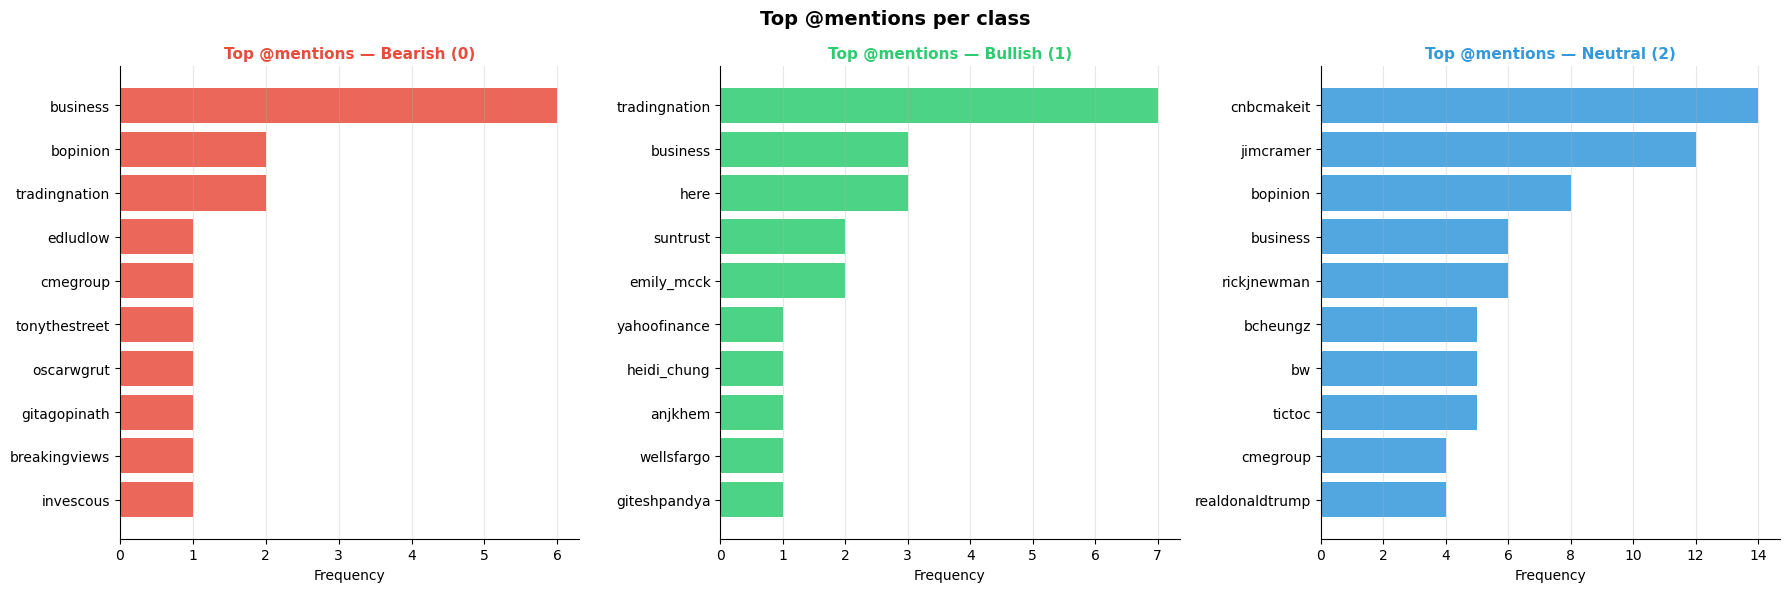

In [18]:
# @Mentions per class 
df_ment = pd.read_csv('train.csv')

def get_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

df_ment['mentions']    = df_ment['text'].apply(get_mentions)
df_ment['n_mentions2'] = df_ment['mentions'].str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset = df_ment[df_ment['label'] == lbl]['mentions']
    all_m  = [m for ms in subset for m in ms]
    top    = Counter(all_m).most_common(10)
    
    if top:
        words_m, counts_m = zip(*top)
        ax.barh(list(reversed(words_m)), list(reversed(counts_m)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Top @mentions — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top @mentions per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




**Mention Analysis - Conclusions**

- **Low frequency of mentions:**  
  The most frequent mentions appear only a small number of times in each class. This suggests that @mentions are not very common in the dataset and are unlikely to provide a strong sentiment signal on their own.

- **No clear class-specific pattern:**  
  Some accounts appear in more than one sentiment class, such as `business`, `bopinion`, `tradingnation`, and `cmegroup`. This indicates that mentions are not strongly associated with a single sentiment class.

- **Neutral class has higher counts:**  
  The Neutral class contains higher mention frequencies, but this is partly expected because it is the largest class in the dataset. Therefore, this does not necessarily mean that mentions are useful for distinguishing Neutral sentiment.

- **Preprocessing decision:**  
  Since mentions mostly identify users or sources rather than the sentiment expressed in the tweet, and because they do not show a clear class-specific pattern, we decided to remove mentions during preprocessing to reduce noise.

### **Hashtag Deep-Dive**

We take a closer look at the hashtags used across classes. Since hashtags like #bullish or #crash can be strong sentiment signals, we segment compound hashtags into their component words (e.g. #stockmarketcrash → stock market crash) to evaluate whether their internal vocabulary differs across classes.

 Examples of hashtag segmentation
  Original  : ['samp', 'economy', 'marketscreener']
  Segmented : ['samp', 'economy', 'market', 'screener']

  Original  : ['bankofnovascotia']
  Segmented : ['bank', 'of', 'nova', 'scotia']

  Original  : ['fedreport', 'economy']
  Segmented : ['fed', 'report', 'economy']

  Original  : ['economy', 'marketscreener']
  Segmented : ['economy', 'market', 'screener']

  Original  : ['imfblog']
  Segmented : ['imf', 'blog']

  Original  : ['economy', 'marketscreener']
  Segmented : ['economy', 'market', 'screener']



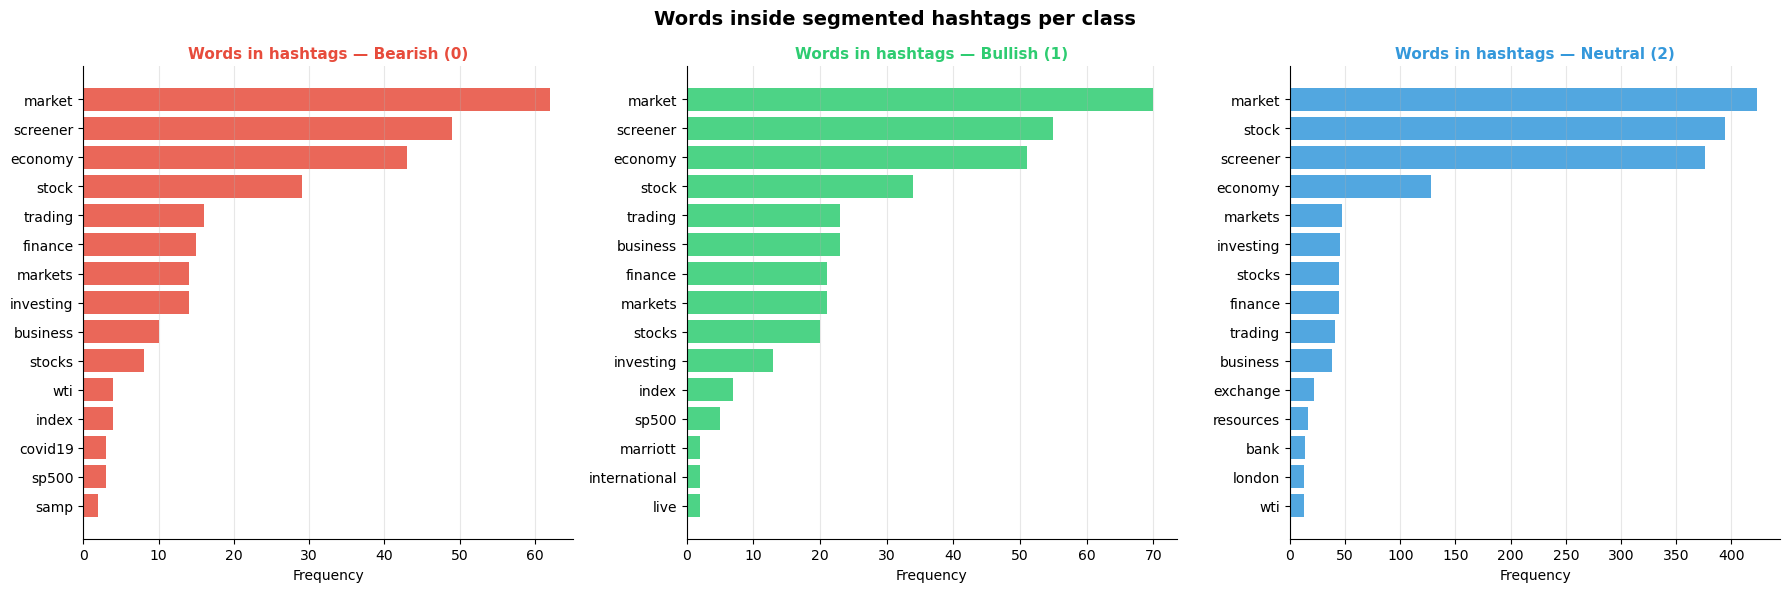

In [19]:
!pip install wordsegment -q
from wordsegment import load as ws_load, segment as ws_segment
ws_load()

df_hash = pd.read_csv('train.csv')

def get_hashtag_words(text):
    hashtags = re.findall(r'#(\w+)', str(text).lower())
    words_h  = []
    for tag in hashtags:
        words_h.extend(ws_segment(tag))
    return words_h

df_hash['hashtag_words'] = df_hash['text'].apply(get_hashtag_words)
df_hash['n_hashtags2']   = df_hash['text'].apply(lambda x: len(re.findall(r'#(\w+)', str(x))))

# Examples
print(' Examples of hashtag segmentation')
mask_h = df_hash['n_hashtags2'] > 0
for _, row in df_hash[mask_h].head(6).iterrows():
    raw = re.findall(r'#(\w+)', str(row['text']).lower())
    print(f'  Original  : {raw}')
    print(f'  Segmented : {row["hashtag_words"]}')
    print()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset_h  = df_hash[df_hash['label'] == lbl]['hashtag_words']
    all_words_h = [w for ws in subset_h for w in ws if len(w) > 2]
    top_h     = Counter(all_words_h).most_common(15)
    
    if top_h:
        words_h, counts_h = zip(*top_h)
        ax.barh(list(reversed(words_h)), list(reversed(counts_h)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Words in hashtags — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Words inside segmented hashtags per class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Hashtag Analysis - Conclusions:**

- **Hashtags mostly represent broad financial topics:**  
  After segmenting compound hashtags, the most frequent words are mainly general market-related terms, such as *market*, *stock*, *economy*, *trading*, *finance*, *investing*, and *business*. These terms appear across the three sentiment classes.

- **Similar patterns across classes:**  
  The same hashtag words appear repeatedly in Bearish, Bullish, and Neutral tweets. This suggests that hashtags mostly describe the topic of the tweet rather than clearly indicating sentiment.

- **Neutral class has higher frequencies:**  
  The Neutral class shows higher absolute counts for hashtag words, especially terms such as *market*, *stock*, and *screener*. This is expected because Neutral is the largest class in the dataset and contains many informational or reporting-style tweets.

- **Preprocessing decision:**  
  Since hashtags do not show a strong class-specific sentiment pattern and mostly add broad topical information, we decided to remove hashtags during preprocessing to reduce noise.

### **Emoji Analysis**

Here we explore which emojis appear most frequently in each class, since symbols like 🚀 or 📉 can carry strong sentiment signal and may be worth converting to text tokens rather than removing.


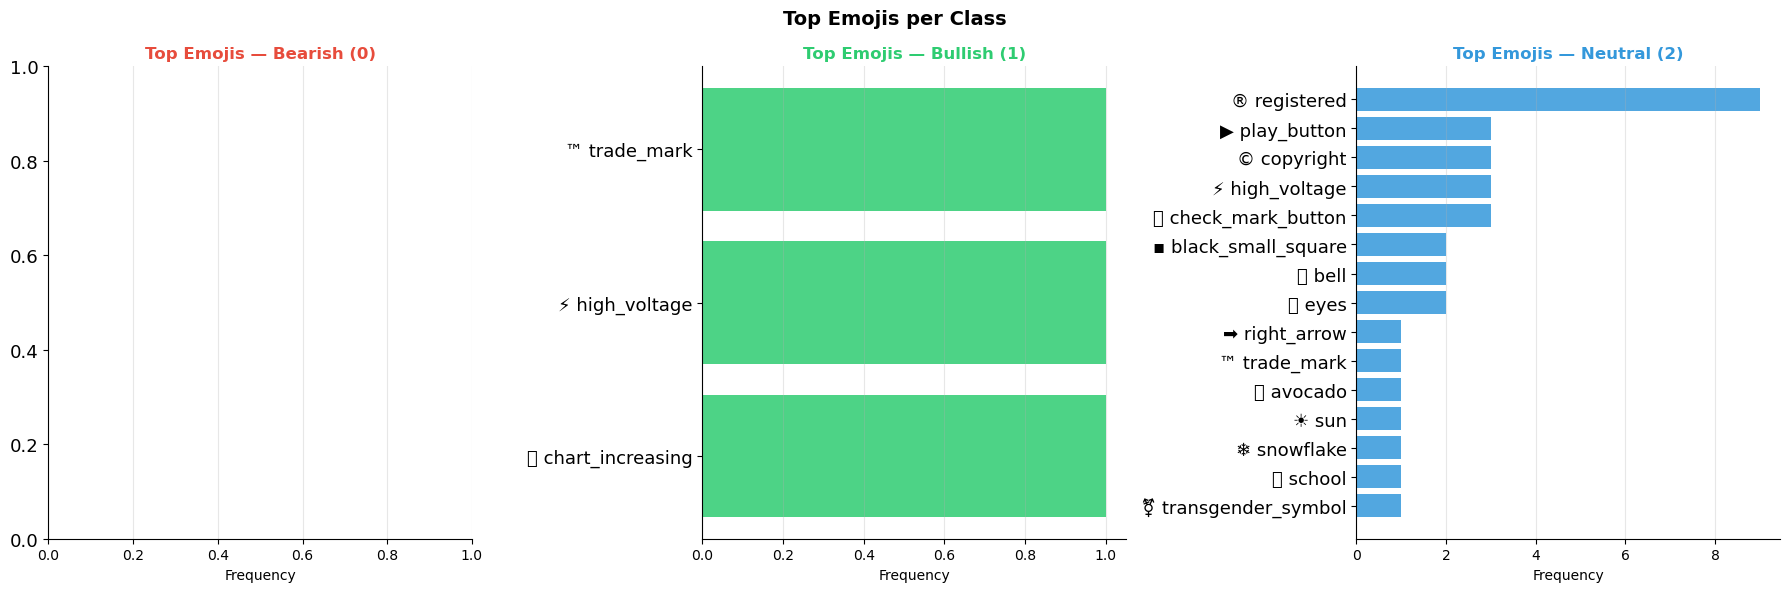

In [20]:
!pip install emoji -q
import emoji
from collections import Counter
import matplotlib.pyplot as plt

df_emj = pd.read_csv('train.csv')

def extract_emojis(text):
    return [ch for ch in str(text) if ch in emoji.EMOJI_DATA]

df_emj['emojis']   = df_emj['text'].apply(extract_emojis)

# ── Create the 3 plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    subset_e = df_emj[df_emj['label'] == lbl]['emojis']
    all_emj  = [e for es in subset_e for e in es]
    top_e    = Counter(all_emj).most_common(15) # Top 15 emojis
    
    if top_e:
        emjs, counts = zip(*top_e)
        
        # To prevent Matplotlib from showing squares instead of the emoji, 
        # we append the text name to the emoji itself (e.g., 🚀 rocket)
        safe_labels = [f"{e} {emoji.demojize(e).replace(':', '')}" for e in emjs]
        
        ax.barh(list(reversed(safe_labels)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
                
    ax.set_title(f'Top Emojis — {CLASS_NAMES[lbl]}',
                 fontsize=12, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Slightly increase Y-axis font size to make emojis more visible
    ax.tick_params(axis='y', labelsize=13)

plt.suptitle('Top Emojis per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Emoji Analysis - Conclusions:**

- **Very low emoji frequency:**  
  Emojis are extremely rare in the dataset. No relevant emojis were found in the Bearish class, only a few isolated emojis appear in the Bullish class, and the Neutral class contains a slightly higher number of emojis, but still with very low frequencies.

- **No strong sentiment pattern:**  
  Although some emojis could theoretically carry sentiment information, such as chart or arrow symbols, their frequency is too low to identify a consistent pattern across sentiment classes.

- **Neutral class contains more symbols:**  
  The Neutral class includes more emoji-like symbols, such as registered trademark, copyright, play button, and other special symbols. However, these appear more related to formatting, sources, or copied text than to financial sentiment.

- **Preprocessing decision:**  
  Since emojis are rare and do not show a clear class-specific sentiment signal, they are unlikely to improve the classification model. Therefore, they can be removed during preprocessing without losing important information.

### **Special Characters**

Punctuation like ! and ? may signal strong sentiment. We analyse whether their frequency differs across classes before deciding whether to remove them during preprocessing.

=== Statistical Significance (Kruskal-Wallis) ===
Symbol               | p-value    | Significance
--------------------------------------------------
exclamation (!)      | 0.0182     | * (Significant)
question (?)         | 0.0000     | *** (Highly Significant)
plus (+)             | 0.0000     | *** (Highly Significant)
minus/dash (-)       | 0.0032     | ** (Very Significant)
less than (<)        | 1.0000     | ns  (Not Significant)
greater than (>)     | 1.0000     | ns  (Not Significant)
percent (%)          | 0.0000     | *** (Highly Significant)
equals (=)           | 0.1379     | ns  (Not Significant)
asterisk (*)         | 0.4167     | ns  (Not Significant)
ampersand (&)        | 0.0000     | *** (Highly Significant)
dollar ($)           | 0.0000     | *** (Highly Significant)
tilde (~)            | 0.6989     | ns  (Not Significant)


<Axes: title={'center': '% of Tweets Containing Special Characters per Class'}, ylabel='Percentage (%)'>

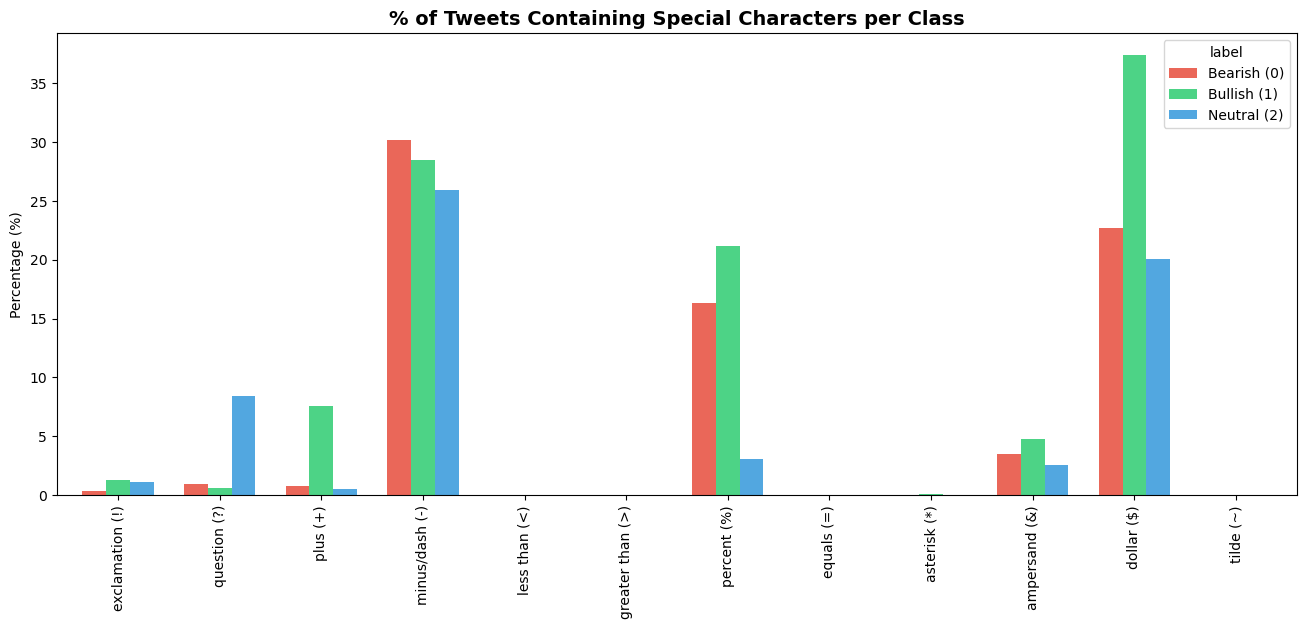

In [21]:
df_sp = pd.read_csv('train.csv')

SPECIAL_CHARS = {
    'exclamation (!)' : r'!',
    'question (?)'    : r'\?',
    'plus (+)'        : r'\+',
    'minus/dash (-)'  : r'-',
    'less than (<)'   : r'<',
    'greater than (>)' : r'>',
    'percent (%)'     : r'%',
    'equals (=)'      : r'=',
    'asterisk (*)'    : r'\*',
    'ampersand (&)'   : r'&',
    'dollar ($)'      : r'\$',
    'tilde (~)'       : r'~'
}

# 1. Count occurrences
char_cols = []
for name, pat in SPECIAL_CHARS.items():
    col = name.split(' ')[0].replace('/', '_') + '_count'
    df_sp[col] = df_sp['text'].apply(lambda x: len(re.findall(pat, str(x))))
    char_cols.append(col)

# 2. Calculate % of tweets with at least 1 occurrence
pct_sp = df_sp.groupby('label')[char_cols].apply(lambda x: (x > 0).mean() * 100).rename(index=CLASS_NAMES)
pct_sp.columns = list(SPECIAL_CHARS.keys())

# 3. Calculate p-values (Kruskal-Wallis test across the 3 classes)
print('=== Statistical Significance (Kruskal-Wallis) ===')
print(f"{'Symbol':<20} | {'p-value':<10} | {'Significance'}")
print("-" * 50)

p_values = {}
for col, name in zip(char_cols, SPECIAL_CHARS.keys()):
    groups = [df_sp[df_sp['label'] == lbl][col] for lbl in [0, 1, 2]]
    
    # FIX: Check if all values in the column are identical (e.g., all zeros)
    if df_sp[col].nunique() <= 1:
        p_val = 1.0  # Force p-value to 1.0 (Not Significant)
    else:
        try:
            stat, p_val = stats.kruskal(*groups)
        except ValueError:
            p_val = 1.0
            
    p_values[name] = p_val
    
    # Add visual markers for quick reading
    if p_val < 0.001:   sig = '*** (Highly Significant)'
    elif p_val < 0.01:  sig = '** (Very Significant)'
    elif p_val < 0.05:  sig = '* (Significant)'
    else:               sig = 'ns  (Not Significant)'
        
    print(f"{name:<20} | {p_val:<10.4f} | {sig}")

# 4. Plotting the single bar chart
fig, ax = plt.subplots(figsize=(16, 6))
color_list = [CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]]

pct_sp.T.plot(kind='bar', ax=ax, color=color_list, width=0.7, edgecolor='none', alpha=0.85)

ax.set_title('% of Tweets Containing Special Characters per Class', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax

#### Special Characters Analysis — Conclusion

- **Several special characters differ across classes:**  
  The Kruskal-Wallis test shows statistically significant differences for several symbols, including `!`, `?`, `+`, `-`, `%`, `&`, and `$`. This suggests that some special characters may carry useful information for distinguishing sentiment classes.

- **Most relevant symbols:**  
  Symbols such as `?`, `+`, `%`, `&`, and `$` show highly significant differences across classes. In particular, `$` is especially relevant in this financial corpus because it is commonly used in cashtags to refer to specific stocks or assets.

- **Class-specific patterns:**  
  The bar chart shows that some symbols are more common in specific classes. For example, `%` and `$` appear more frequently in Bullish tweets, while `?` appears more often in Neutral tweets. This indicates that these characters may reflect different types of financial communication.

- **Non-significant symbols:**  
  Some symbols, such as `<`, `>`, `=`, `*`, and `~`, do not show significant differences across sentiment classes. These characters are unlikely to provide useful sentiment information.

- **Preprocessing decision:**  
  Based on this analysis, we decided to preserve or explicitly handle the statistically significant symbols before applying general text cleaning. Non-informative symbols can be removed, while relevant symbols such as `$`, `%`, `+`, `?`, and `!` should be treated carefully because they may contain useful sentiment or financial information.

[↑ Back to TOC](#toc)

<a class='anchor' id='2-5'></a>
## **2.5 Key Findings**

In [22]:
print('=' * 65)
print('DATA EXPLORATION SUMMARY')
print('=' * 65)
print(f'Total tweets (train):            {len(df):,}')
print(f'Unique vocabulary (no stopwords):{len(vocab):,} words')
print(f'Total tokens:                    {len(all_tokens):,}')
print(f'Avg tweet length:                {df["n_words"].mean():.1f} words / {df["n_chars"].mean():.0f} chars')
print()
print('Class distribution:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Majority-class baseline: {majority_acc:.1f}%')
print()
print('Key findings:')
print('  1. Class imbalance is moderate → use class_weight="balanced"')
print('  2. Financial keywords appear in expected classes → coherent dataset')
print('  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF')
print('  4. Most cashtags appear across all classes → normalise to TICKER')
print('  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate')
print('=' * 65)

DATA EXPLORATION SUMMARY
Total tweets (train):            9,543
Unique vocabulary (no stopwords):14,663 words
Total tokens:                    73,843
Avg tweet length:                12.2 words / 86 chars

Class distribution:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Majority-class baseline: 64.7%

Key findings:
  1. Class imbalance is moderate → use class_weight="balanced"
  2. Financial keywords appear in expected classes → coherent dataset
  3. Bigrams are informative → use ngram_range=(1,2) in TF-IDF
  4. Most cashtags appear across all classes → normalise to TICKER
  5. Lexical dispersion confirms that min_df=2 in TF-IDF is appropriate


[↑ Back to TOC](#toc)

<a class='anchor' id='3'></a>
---
## 3. Data Preprocessing

Two separate preprocessing pipelines are used:
- **Classical pipeline** (BoW / TF-IDF / Word2Vec + Traditional ML): full cleaning with lemmatization.
- **Transformer pipeline** (BERT / FinBERT / RoBERTa): minimal cleaning only — the tokenizer handles the rest.

**Techniques applied (≥4 required):** Lowercasing · URL removal · @mention removal · Hashtag normalisation · Cashtag normalisation · Non-alpha regex · Stopword removal · Lemmatization · `word_tokenize`

<a class='anchor' id='3-1'></a>
### 3.1 Step-by-step Demonstration

In [23]:
#TODO por isto em baixo a fazer o q vai acontecer, os hashtags é para por como frase ou para tirar??? pq é q a cena das STOP words n funciona???? é pq o len > 2 e do keep set
# por isto aqui ou depois da criaçao da funçao????

In [26]:
tweet_example = "$TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%"
t = tweet_example
steps = [
    ('1. Original',             t),
    ('2. Lowercase',            t := t.lower()),
    ('3. Remove URLs',          t := re.sub(r'http\S+|www\S+','',t)),
    ('4. Remove @mentions',     t := re.sub(r'@\w+','',t)),
    ('5. Hashtags → words',     t := re.sub(r'#(\w+)',r'\1',t)),
    ('6. Cashtags → ticker',    t := re.sub(r'\$[a-zA-Z]{1,5}','ticker',t)),
    ('7. Letters only (regex)', t := re.sub(r'[^a-zA-Z\s?+%&!$-]',' ',t)),
    ('8. Remove stopwords',     t := ' '.join(w for w in t.split() if w not in STOP)),
    ('9. Lemmatization',        t := ' '.join(lemma.lemmatize(w) for w in t.split())),
]

for step_name, step_text in steps:
    print(f'{step_name:<30} → {step_text.strip()}')


1. Original                    → $TSLA beats earnings! #Bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
2. Lowercase                   → $tsla beats earnings! #bullish #stocks @elonmusk https://t.co/abc123 up 5.3%
3. Remove URLs                 → $tsla beats earnings! #bullish #stocks @elonmusk  up 5.3%
4. Remove @mentions            → $tsla beats earnings! #bullish #stocks   up 5.3%
5. Hashtags → words            → $tsla beats earnings! bullish stocks   up 5.3%
6. Cashtags → ticker           → ticker beats earnings! bullish stocks   up 5.3%
7. Letters only (regex)        → ticker beats earnings! bullish stocks   up    %
8. Remove stopwords            → ticker beats earnings! bullish stocks up %
9. Lemmatization               → ticker beat earnings! bullish stock up %


[↑ Back to TOC](#toc)

<a class='anchor' id='3-2'></a>
### 3.2 Lemmatization vs Stemming

Lemmatization is chosen: it preserves recognisable word forms, crucial for financial text (e.g. *"bullish"* should not become *"bulli"*).

In [27]:
financial_words_cmp = [
    'beats','beating','beaten','misses','missing','missed',
    'earnings','earning','rises','rising','raised',
    'falling','fallen','falls','bullish','bearish','investing','investors',
]
print(f"{'Word':<18} {'Lemma':<18} {'Stem':<18} Notes")
print('-'*70)
for word in financial_words_cmp:
    l = lemma.lemmatize(word)
    s = stemmer.stem(word)
    note = '← different!' if l != s else ''
    print(f'{word:<18} {l:<18} {s:<18} {note}')
print('\nDecision: Lemmatization used in the classical pipeline (use_lemma=True).')

Word               Lemma              Stem               Notes
----------------------------------------------------------------------
beats              beat               beat               
beating            beating            beat               ← different!
beaten             beaten             beaten             
misses             miss               miss               
missing            missing            miss               ← different!
missed             missed             miss               ← different!
earnings           earnings           earn               ← different!
earning            earning            earn               ← different!
rises              rise               rise               
rising             rising             rise               ← different!
raised             raised             rais               ← different!
falling            falling            fall               ← different!
fallen             fallen             fallen             
falls           

[↑ Back to TOC](#toc)

<a class='anchor' id='3-3'></a>
### 3.3 Preprocessing Functions

In [ ]:
# def preprocess_classical(text_list, use_lemma=True, use_stemmer=False):
#     """
#     Full text cleaning for classical ML models (BoW / TF-IDF / Word2Vec).
#     Steps: lowercase → URLs → @mentions → hashtags → cashtags
#            → regex (keep letters AND special chars) → stopwords → word_tokenize → lemmatize.
#     """
#     results = []
#     valid_symbols = set('!?+-%&$')
    
    
#     for text in tqdm(text_list, desc='Classical preprocessing'):
#         text = str(text).lower()
#         text = re.sub(r'http\S+|www\S+', '', text)
#         text = re.sub(r'@\w+', '', text)
#         text = re.sub(r'#(\w+)', r'\1', text)
#         text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text)
        
#         text = re.sub(r'[^a-zA-Z\s?+%&!$-]', ' ', text)
        
#         tokens = word_tokenize(text)
        
#         tokens = [w for w in tokens if w not in STOP and (len(w) > 2 or w in valid_symbols)]
        
#         if use_lemma:    tokens = [lemma.lemmatize(w) for w in tokens]
#         if use_stemmer:  tokens = [stemmer.stem(w) for w in tokens]
        
#         results.append(' '.join(tokens))
#     return results

def preprocess_classical(text_list, use_lemma=True, use_stemmer=False):
    """
    Full text cleaning for classical ML models (BoW / TF-IDF / Word2Vec).
    """
    results = []
    valid_symbols = set('!?+-%&$')
    
    financial_keep_set = {'up', 'down', 'above', 'below', 'over', 'under', 'off', 'not', 'no', 'more', 'most', 'too', 'further', 'few'}
    
    for text in tqdm(text_list, desc='Classical preprocessing'):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'\$[a-zA-Z]{1,5}', 'ticker', text)
        
        text = re.sub(r'[^a-zA-Z\s?+%&!$-]', ' ', text)
        
        tokens = word_tokenize(text)
        
        tokens = [w for w in tokens if w not in STOP and (len(w) > 2 or w in valid_symbols or w in financial_keep_set)]
        
        if use_lemma:    tokens = [lemma.lemmatize(w) for w in tokens]
        if use_stemmer:  tokens = [stemmer.stem(w) for w in tokens]
        
        results.append(' '.join(tokens))
    return results

def preprocess_transformer(text_list):
    """
    Minimal cleaning for Transformer models (BERT / FinBERT / RoBERTa).
    """
    results = []
    for text in tqdm(text_list, desc='Transformer preprocessing'):
        text = str(text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        results.append(text)
    return results

[↑ Back to TOC](#toc)

<a class='anchor' id='3-4'></a>
### 3.4 Apply to Full Training Set

> **Note on leakage:** `preprocess_classical` and `preprocess_transformer` are deterministic — they learn nothing from the data. They can safely be applied to the full dataset before the CV split. The only operations that must be fitted exclusively on the train fold are vectorisers (TF-IDF, Word2Vec) — these are handled inside `Pipeline` objects in Section 6.

In [29]:
print('Applying classical pipeline (lemmatization)...')
df['text_lemma'] = preprocess_classical(df['text'].tolist(), use_lemma=True, use_stemmer=False)

print('Applying classical pipeline (stemming — for comparison)...')
df['text_stem']  = preprocess_classical(df['text'].tolist(), use_lemma=False, use_stemmer=True)

print('Applying transformer pipeline...')
df['text_transformer'] = preprocess_transformer(df['text'].tolist())

print(f'Columns available: {list(df.columns)}')

Applying classical pipeline (lemmatization)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 6062.35it/s]


Applying classical pipeline (stemming — for comparison)...


Classical preprocessing: 100%|██████████| 9543/9543 [00:01<00:00, 5572.43it/s]


Applying transformer pipeline...


Transformer preprocessing: 100%|██████████| 9543/9543 [00:00<00:00, 123912.97it/s]

Columns available: ['text', 'label', 'n_words', 'n_chars', 'n_hashtags', 'n_mentions', 'n_urls', 'n_numbers', 'has_cashtag', 'has_hashtag', 'has_mention', 'has_url', 'has_number', 'text_lemma', 'text_stem', 'text_transformer']


[↑ Back to TOC](#toc)

<a class='anchor' id='3-5'></a>
### 3.5 Before / After Comparison

In [30]:
print('Before / after preprocessing — 5 examples:\n')
for i in range(5):
    print(f'[{i}] ORIGINAL    : {df["text"].iloc[i]}')
    print(f'    LEMMA       : {df["text_lemma"].iloc[i]}')
    print(f'    STEM        : {df["text_stem"].iloc[i]}')
    print(f'    TRANSFORMER : {df["text_transformer"].iloc[i]}')
    print()

Before / after preprocessing — 5 examples:

[0] ORIGINAL    : $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
    LEMMA       : ticker - jpmorgan reel expectation beyond meat
    STEM        : ticker - jpmorgan reel expect beyond meat
    TRANSFORMER : $BYND - JPMorgan reels in expectations on Beyond Meat

[1] ORIGINAL    : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3
    LEMMA       : ticker ticker - nomura point booking weakness carnival royal caribbean
    STEM        : ticker ticker - nomura point book weak carniv royal caribbean
    TRANSFORMER : $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean

[2] ORIGINAL    : $CX - Cemex cut at Credit Suisse, J.P. Morgan on weak building outlook https://t.co/KN1g4AWFIb
    LEMMA       : ticker - cemex cut credit suisse morgan weak building outlook
    STEM        : ticker - cemex cut credit suiss morgan weak build outlook
    T

[↑ Back to TOC](#toc)

<a class='anchor' id='3-6'></a>
### 3.6 Vocabulary Impact

In [31]:
def get_vocab(series):
    tokens = []
    for text in series: tokens.extend(str(text).split())
    return set(tokens), len(tokens)

v_orig,  t_orig  = get_vocab(df['text'])
v_lemma, t_lemma = get_vocab(df['text_lemma'])
v_stem,  t_stem  = get_vocab(df['text_stem'])

print(f"{'Version':<20} {'Total tokens':>15} {'Unique vocab':>15}")
print('-'*52)
print(f"{'Original':<20} {t_orig:>15,} {len(v_orig):>15,}")
print(f"{'Lemmatization':<20} {t_lemma:>15,} {len(v_lemma):>15,}")
print(f"{'Stemming':<20} {t_stem:>15,} {len(v_stem):>15,}")
print()
print(f'Vocab reduction (lemma vs original): {(1-len(v_lemma)/len(v_orig))*100:.1f}%')
print(f'Vocab reduction (stem  vs original): {(1-len(v_stem)/len(v_orig))*100:.1f}%')

Version                 Total tokens    Unique vocab
----------------------------------------------------
Original                     116,218          31,609
Lemmatization                 81,713          13,043
Stemming                      81,713          11,115

Vocab reduction (lemma vs original): 58.7%
Vocab reduction (stem  vs original): 64.8%


[↑ Back to TOC](#toc)

<a class='anchor' id='3-7'></a>
### 3.7 Tweets with Little Content After Cleaning

Tweets that become empty or have fewer than 3 tokens after cleaning are problematic for models — important to identify them now.

Empty tweets after cleaning (0 tokens): 8
Tweets with fewer than 3 tokens:        96
Tweets with useful content (≥3 tokens): 9,447


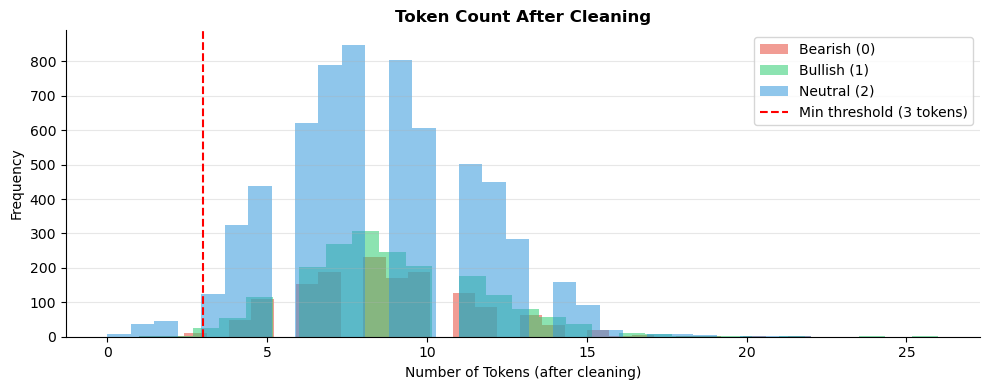


Tweets with exactly 3 word(s): 158
Distribution per class:
label
Neutral (2)    124
Bullish (1)     24
Bearish (0)     10
Name: count, dtype: int64

Examples (showing up to 100 rows):
                                                                                                                          text                      tokens_clean  label
78                                                                                                 Jefferies warns on L Brands         [jefferies, warns, brand]      0
110                                                                                             Sirius downgraded on valuation   [sirius, downgraded, valuation]      0
148                                                                                     $NBY Rated buy https://t.co/xWbLXU1yOY              [ticker, rated, buy]      1
216                                                                                                Citi reels in PT on Nu Skin                [

In [32]:
# Create token lists directly from your preprocessed text_lemma string
df['tokens_clean']   = df['text_lemma'].str.split().fillna('').apply(list)
df['n_tokens_clean'] = df['tokens_clean'].str.len()

empty        = (df['n_tokens_clean'] == 0).sum()
short_tweets = (df['n_tokens_clean'] < 3).sum()

print(f'Empty tweets after cleaning (0 tokens): {empty}')
print(f'Tweets with fewer than 3 tokens:        {short_tweets}')
print(f'Tweets with useful content (≥3 tokens): {(df["n_tokens_clean"] >= 3).sum():,}')

# Plotting the Distribution 
fig, ax = plt.subplots(figsize=(10, 4))
for lbl in [0,1,2]:
    ax.hist(df[df['label']==lbl]['n_tokens_clean'], bins=30, alpha=0.55,
            color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Min threshold (3 tokens)')
ax.set_title('Token Count After Cleaning', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Tokens (after cleaning)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

# Deep-Dive: Tweets with Exactly 2 Words 
df['n_words'] = df['n_tokens_clean']

for n in [3]:
    subset = df[df['n_words'] == n]
    print()
    print(f'Tweets with exactly {n} word(s): {len(subset)}')
    print(f'Distribution per class:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExamples (showing up to 100 rows):')
    print(subset[['text', 'tokens_clean', 'label']].head(100).to_string())

for n in [2]:
    subset = df[df['n_words'] == n]
    print()
    print(f'Tweets with exactly {n} word(s): {len(subset)}')
    print(f'Distribution per class:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExamples (showing up to 100 rows):')
    print(subset[['text', 'tokens_clean', 'label']].head(100).to_string())

for n in [1]:
    subset = df[df['n_words'] == n]
    print()
    print(f'Tweets with exactly {n} word(s): {len(subset)}')
    print(f'Distribution per class:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExamples (showing up to 100 rows):')
    print(subset[['text', 'tokens_clean', 'label']].head(100).to_string())

for n in [0]:
    subset = df[df['n_words'] == n]
    print()
    print(f'Tweets with exactly {n} word(s): {len(subset)}')
    print(f'Distribution per class:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExamples (showing up to 100 rows):')
    print(subset[['text', 'tokens_clean', 'label']].head(100).to_string())

# # Drop Completely Empty Rows 
# # Crucial step: Completely empty tweets (0 tokens) must be removed so they don't break the vectorisers later
# if empty > 0:
#     mask_empty = df['n_tokens_clean'] == 0
#     df = df[~mask_empty].reset_index(drop=True)
#     print(f'\nDataset size after removing completely empty rows: {len(df)} tweets')


In [33]:
df.iloc[6953]

text                U.S. stocks are 📈 https://t.co/2cVbN4AIF4 http...
label                                                               1
n_words                                                             1
n_chars                                                            65
n_hashtags                                                          0
n_mentions                                                          0
n_urls                                                              2
n_numbers                                                           0
has_cashtag                                                     False
has_hashtag                                                     False
has_mention                                                     False
has_url                                                          True
has_number                                                      False
text_lemma                                                      stock
text_stem           

[↑ Back to TOC](#toc)

<a class='anchor' id='4'></a>
---
## 4. Corpus Split — Stratified K-Fold

**Stratified K-Fold (k=5)** ensures each fold preserves class proportions.  
Vectoriser / model `.fit()` always happens *inside* each fold via `Pipeline` → no data leakage.

In [34]:
from sklearn.model_selection import StratifiedKFold

X_classical   = df['text_lemma']
X_transformer = df['text_transformer']
y             = df['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Fold distribution (Stratified K-Fold, k=5):')
print(f"{'Fold':<8} {'Train':>8} {'Val':>8} {'Bearish%':>10} {'Bullish%':>10} {'Neutral%':>10}")
print('-'*60)
folds = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_classical, y)):
    y_val_fold = y.iloc[val_idx]
    pcts = y_val_fold.value_counts(normalize=True).sort_index() * 100
    folds.append((train_idx, val_idx))
    print(f"Fold {fold+1:<4} {len(train_idx):>8,} {len(val_idx):>8,} "
          f"{pcts.get(0,0):>9.1f}% {pcts.get(1,0):>9.1f}% {pcts.get(2,0):>9.1f}%")



Fold distribution (Stratified K-Fold, k=5):
Fold        Train      Val   Bearish%   Bullish%   Neutral%
------------------------------------------------------------
Fold 1       7,634    1,909      15.1%      20.1%      64.7%
Fold 2       7,634    1,909      15.1%      20.1%      64.7%
Fold 3       7,634    1,909      15.1%      20.2%      64.7%
Fold 4       7,635    1,908      15.1%      20.2%      64.7%
Fold 5       7,635    1,908      15.1%      20.2%      64.7%


[↑ Back to TOC](#toc)

<a class='anchor' id='5'></a>
---
## 5. Feature Engineering

| Method | Pipeline | Notes |
|---|---|---|
| **BoW / TF-IDF** | Classical | `CountVectorizer` and `TfidfVectorizer` |
| **Word2Vec** | Classical | Gensim; tweet → mean of word vectors |
| **Transformer Encoder** | Transformer | FinBERT, BERT, RoBERTa — [CLS] embeddings |

<a class='anchor' id='5-1'></a>
### 5.1 BoW & TF-IDF

In [35]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Defined here, but always fitted INSIDE a sklearn Pipeline to prevent leakage
bow_vectorizer   = CountVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, token_pattern=r"[^\s]+")
tfidf_vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                    sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")

print('CountVectorizer (BoW):')
print(f'  max_features={bow_vectorizer.max_features}, ngram_range={bow_vectorizer.ngram_range}')
print('TfidfVectorizer:')
print(f'  max_features={tfidf_vectorizer.max_features}, ngram_range={tfidf_vectorizer.ngram_range}')


CountVectorizer (BoW):
  max_features=20000, ngram_range=(1, 2)
TfidfVectorizer:
  max_features=20000, ngram_range=(1, 2)


[↑ Back to TOC](#toc)

<a class='anchor' id='5-2'></a>
### 5.2 Word2Vec — Mean Embedding Transformer

In [36]:
from gensim.models import Word2Vec
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MeanWord2VecTransformer(BaseEstimator, TransformerMixin):
    """
    sklearn-compatible transformer that:
    1. Trains a Word2Vec model on the input texts (fit).
    2. Converts each text to the mean of its word vectors (transform).
    Fully compatible with cross_val_predict and Pipeline — no leakage.
    """
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10):
        self.vector_size = vector_size
        self.window      = window
        self.min_count   = min_count
        self.epochs      = epochs

    def fit(self, X, y=None):
        sentences  = [text.split() for text in X]
        self.model = Word2Vec(sentences=sentences, vector_size=self.vector_size,
                              window=self.window, min_count=self.min_count,
                              workers=4, seed=42, epochs=self.epochs)
        return self

    def transform(self, X):
        embeddings = []
        for text in X:
            tokens = [w for w in text.split() if w in self.model.wv]
            if tokens:
                embeddings.append(np.mean(self.model.wv[tokens], axis=0))
            else:
                embeddings.append(np.zeros(self.vector_size))
        return np.array(embeddings)


[↑ Back to TOC](#toc)

<a class='anchor' id='5-3'></a>
### 5.3 Transformer Encoder Embeddings (FinBERT / BERT / RoBERTa)

In [37]:
# pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch

def get_transformer_embeddings(texts, model_name='ProsusAI/finbert',
                                batch_size=32, max_len=128):
    """
    Extracts [CLS] token embeddings from a pre-trained transformer encoder.
    
    Models:
      'ProsusAI/finbert'        — trained on financial text (best fit)
      'bert-base-uncased'       — general BERT baseline
      'distilbert-base-uncased' — lighter, faster BERT  [Extra: +0.50 pts]
      'roberta-base'            — improved BERT          [Extra: +0.50 pts]
    """
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModel.from_pretrained(model_name).to(device)
    model.eval()
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Embedding [{model_name}]'):
        batch   = list(texts[i:i+batch_size])
        encoded = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_len, return_tensors='pt').to(device)
        with torch.no_grad():
            output = model(**encoded)
        cls_emb = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_emb)
    return np.vstack(all_embeddings)


[↑ Back to TOC](#toc)

<a class='anchor' id='6'></a>
---
## 6. Classification Models

- **Classical ML** uses BoW / TF-IDF / Word2Vec features inside a `Pipeline`.
- **Fine-tuned Transformers** are trained end-to-end.
- All models evaluated with Stratified K-Fold CV.
- `class_weight='balanced'` used throughout.

<a class='anchor' id='6-1'></a>
### 6.1 Evaluation Helper

In [38]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

def evaluate_model(y_true, y_pred, model_name='Model'):
    """Print classification report and plot confusion matrix."""
    print(f'\n{model_name}')
    print(classification_report(y_true, y_pred,
                                 target_names=['Bearish','Bullish','Neutral']))
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Bearish','Bullish','Neutral'],
                yticklabels=['Bearish','Bullish','Neutral'], ax=ax)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    ax.set_ylabel('True label'); ax.set_xlabel('Predicted label')
    plt.tight_layout(); plt.show()
    return {
        'model':       model_name,
        'accuracy':    accuracy_score(y_true, y_pred),
        'f1_macro':    f1_score(y_true, y_pred, average='macro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
    }

results_table = []

[↑ Back to TOC](#toc)

<a class='anchor' id='6-2'></a>
### 6.2 Traditional ML — TF-IDF / BoW Pipeline

Running CV: LR + TF-IDF...

LR + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.58      0.67      0.62      1442
     Bullish       0.69      0.76      0.72      1923
     Neutral       0.90      0.84      0.87      6178

    accuracy                           0.80      9543
   macro avg       0.72      0.76      0.74      9543
weighted avg       0.81      0.80      0.80      9543



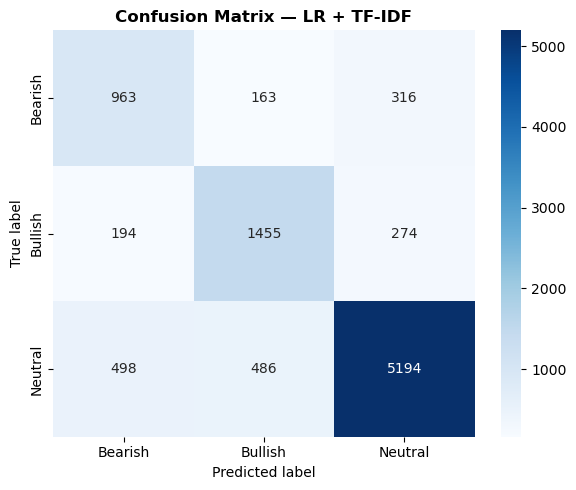

Running CV: XGBoost + TF-IDF...

XGBoost + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.80      0.43      0.56      1442
     Bullish       0.78      0.60      0.68      1923
     Neutral       0.81      0.95      0.87      6178

    accuracy                           0.80      9543
   macro avg       0.79      0.66      0.70      9543
weighted avg       0.80      0.80      0.79      9543



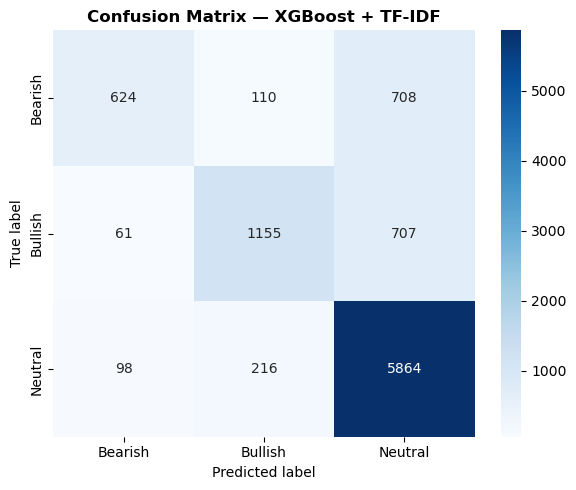

Running CV: MLP + TF-IDF...

MLP + TF-IDF
              precision    recall  f1-score   support

     Bearish       0.69      0.51      0.59      1442
     Bullish       0.73      0.70      0.71      1923
     Neutral       0.85      0.91      0.88      6178

    accuracy                           0.81      9543
   macro avg       0.76      0.71      0.73      9543
weighted avg       0.80      0.81      0.80      9543



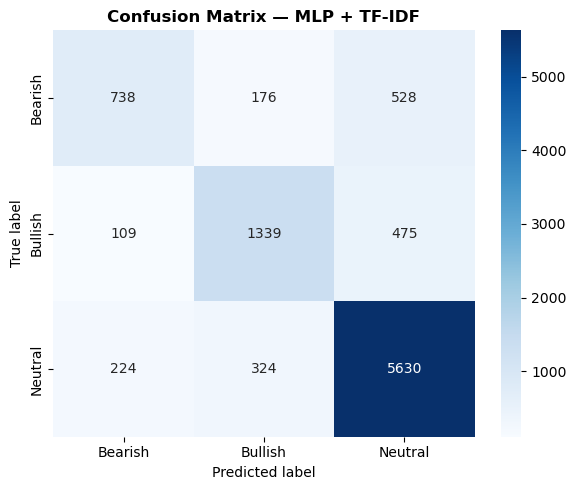

Running CV: RF + BoW...

RF + BoW
              precision    recall  f1-score   support

     Bearish       0.82      0.43      0.57      1442
     Bullish       0.78      0.63      0.70      1923
     Neutral       0.81      0.95      0.88      6178

    accuracy                           0.81      9543
   macro avg       0.80      0.67      0.71      9543
weighted avg       0.81      0.81      0.79      9543



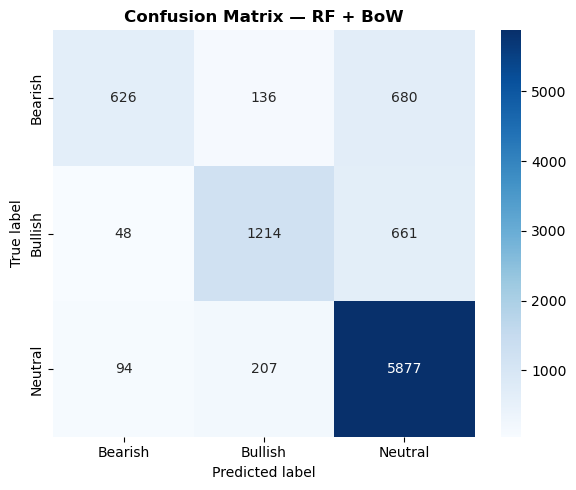

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_predict
from xgboost import XGBClassifier

classical_models = {
    'LR + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'XGBoost + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   XGBClassifier(n_estimators=300, learning_rate=0.1,
                                eval_metric='mlogloss', random_state=42))
    ]),
    'MLP + TF-IDF': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   sublinear_tf=True, min_df=2, token_pattern=r"[^\s]+")),
        ('clf',   MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                                random_state=42, early_stopping=True))
    ]),
    'RF + BoW': Pipeline([
        ('bow', CountVectorizer(max_features=15000, ngram_range=(1,1), min_df=2, token_pattern=r"[^\s]+")),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        n_jobs=-1, random_state=42))
    ]),
}

for name, pipeline in classical_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-3'></a>
### 6.3 Traditional ML — Word2Vec Pipeline

Running CV: LR + Word2Vec...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



LR + Word2Vec
              precision    recall  f1-score   support

     Bearish       0.29      0.33      0.31      1442
     Bullish       0.43      0.53      0.48      1923
     Neutral       0.81      0.72      0.77      6178

    accuracy                           0.63      9543
   macro avg       0.51      0.53      0.52      9543
weighted avg       0.66      0.63      0.64      9543



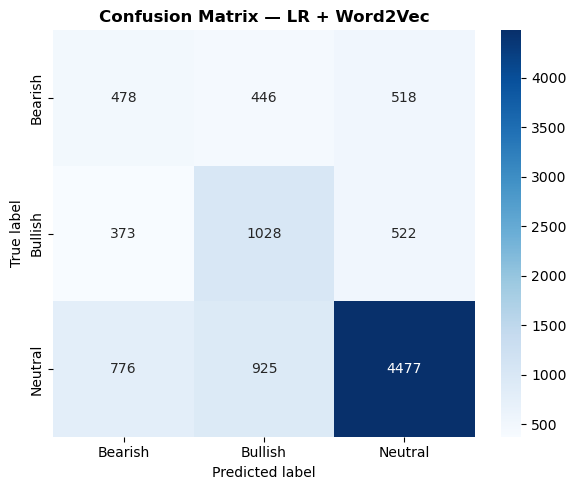

Running CV: MLP + Word2Vec...

MLP + Word2Vec
              precision    recall  f1-score   support

     Bearish       0.39      0.07      0.11      1442
     Bullish       0.53      0.44      0.48      1923
     Neutral       0.74      0.92      0.82      6178

    accuracy                           0.70      9543
   macro avg       0.55      0.48      0.47      9543
weighted avg       0.65      0.70      0.65      9543



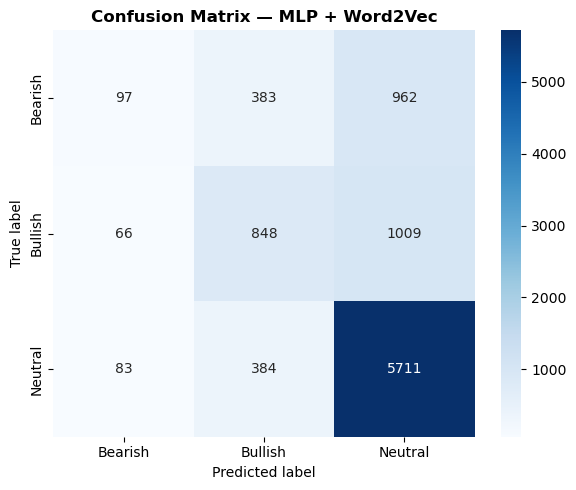

In [40]:
w2v_models = {
    'LR + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + Word2Vec': Pipeline([
        ('w2v', MeanWord2VecTransformer(vector_size=100, window=5, min_count=2, epochs=10)),
        ('clf', MLPClassifier(hidden_layer_sizes=(256,128), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in w2v_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_classical, y, cv=skf)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-4'></a>
### 6.4 Transformer Encoder + Classifier Head

In [41]:
# Extract FinBERT embeddings once (cache to avoid re-running)
print('Extracting FinBERT embeddings ...')
X_finbert = get_transformer_embeddings(
    X_transformer.tolist(), model_name='ProsusAI/finbert', batch_size=32
)
print(f'FinBERT embedding shape: {X_finbert.shape}')

# Optional — extra credit (+0.50 pts each)
# X_bert    = get_transformer_embeddings(X_transformer.tolist(), model_name='bert-base-uncased')
# X_roberta = get_transformer_embeddings(X_transformer.tolist(), model_name='roberta-base')

Extracting FinBERT embeddings ...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Embedding [ProsusAI/finbert]:   0%|          | 0/299 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Embedding [ProsusAI/finbert]:   0%|          | 1/299 [00:03<16:58,  3.42s/it]


KeyboardInterrupt: 

Running CV: LR + FinBERT...

LR + FinBERT
              precision    recall  f1-score   support

     Bearish       0.55      0.72      0.63      1442
     Bullish       0.64      0.75      0.69      1923
     Neutral       0.90      0.78      0.84      6170

    accuracy                           0.77      9535
   macro avg       0.70      0.75      0.72      9535
weighted avg       0.80      0.77      0.78      9535



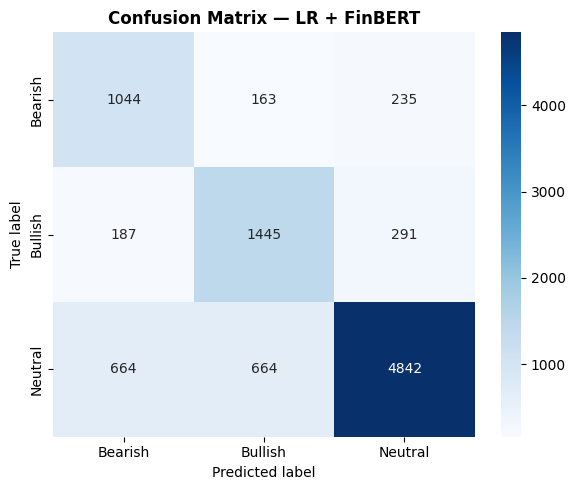

Running CV: MLP + FinBERT...

MLP + FinBERT
              precision    recall  f1-score   support

     Bearish       0.76      0.64      0.70      1442
     Bullish       0.77      0.74      0.75      1923
     Neutral       0.87      0.92      0.89      6170

    accuracy                           0.84      9535
   macro avg       0.80      0.77      0.78      9535
weighted avg       0.84      0.84      0.84      9535



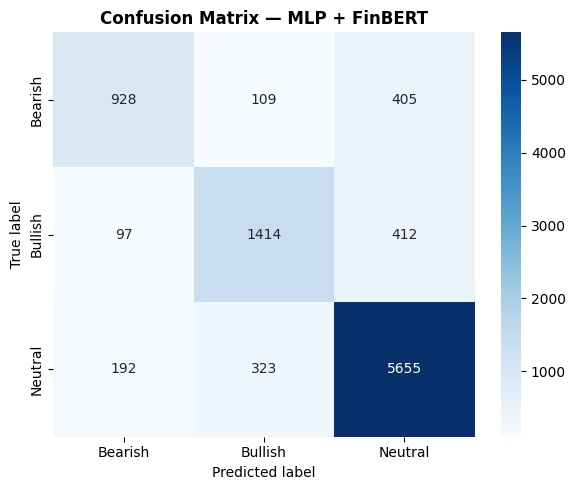

In [ ]:
from sklearn.preprocessing import StandardScaler

encoder_models = {
    'LR + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'MLP + FinBERT': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(512,256), max_iter=300,
                              random_state=42, early_stopping=True))
    ]),
}

for name, pipeline in encoder_models.items():
    print(f'Running CV: {name}...')
    y_pred = cross_val_predict(pipeline, X_finbert, y, cv=skf, n_jobs=-1)
    res = evaluate_model(y, y_pred, model_name=name)
    results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='6-5'></a>
### 6.5 Fine-tuned FinBERT (End-to-end Transformer)

In [ ]:
# pip install transformers torch datasets
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset

MODEL_NAME = 'ProsusAI/finbert'
tokenizer_ft = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer_ft(batch['text'], padding='max_length',
                        truncation=True, max_length=128)

# Use fold 0 for fine-tuning demonstration
train_idx, val_idx = folds[0]
train_ds = Dataset.from_dict({'text': X_transformer.iloc[train_idx].tolist(),
                               'label': y.iloc[train_idx].tolist()})
val_ds   = Dataset.from_dict({'text': X_transformer.iloc[val_idx].tolist(),
                               'label': y.iloc[val_idx].tolist()})
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)

model_ft = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

training_args = TrainingArguments(
    output_dir='./finbert_finetuned',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    logging_steps=50,
    seed=42,
)
trainer = Trainer(model=model_ft, args=training_args,
                  train_dataset=train_ds, eval_dataset=val_ds)
trainer.train()
print('FinBERT fine-tuning complete.')

Map:   0%|          | 0/7628 [00:00<?, ? examples/s]

Map:   0%|          | 0/1907 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,0.434553,0.390602
2,0.262132,0.419004
3,0.131466,0.545959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FinBERT fine-tuning complete.



FinBERT Fine-tuned
              precision    recall  f1-score   support

     Bearish       0.85      0.64      0.73       289
     Bullish       0.84      0.76      0.80       384
     Neutral       0.87      0.95      0.91      1234

    accuracy                           0.86      1907
   macro avg       0.85      0.78      0.81      1907
weighted avg       0.86      0.86      0.86      1907



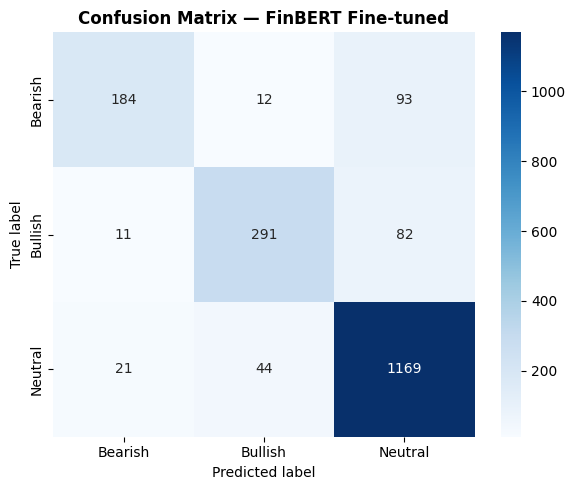

In [ ]:
preds_ft   = trainer.predict(val_ds)
y_pred_ft  = preds_ft.predictions.argmax(axis=1)
y_true_ft  = y.iloc[val_idx].tolist()
res = evaluate_model(y_true_ft, y_pred_ft, model_name='FinBERT Fine-tuned')
results_table.append(res)

[↑ Back to TOC](#toc)

<a class='anchor' id='7'></a>
---
## 7. Evaluation & Analysis

### Metric Interpretation in Context

| Metric | Meaning |
|---|---|
| **Accuracy** | Overall correctness — misleading if classes are imbalanced |
| **F1-Macro** | Average F1 across all 3 classes with equal weight — **primary metric** |
| **F1-Weighted** | F1 weighted by class support — closer to accuracy |
| **Recall per class** | Missing a Bearish signal (low Recall) has real financial cost |
| **Precision per class** | Wrongly flagging Neutral as Bullish (low Precision) misleads investors |

In [ ]:
results_df = pd.DataFrame(results_table).sort_values('f1_macro', ascending=False)
results_df[['accuracy','f1_macro','f1_weighted']] = \
    results_df[['accuracy','f1_macro','f1_weighted']].round(4)
print(results_df.to_string(index=False))

             model  accuracy  f1_macro  f1_weighted
FinBERT Fine-tuned    0.8621    0.8106       0.8576
     MLP + FinBERT    0.8387    0.7810       0.8358
       LR + TF-IDF    0.7900    0.7234       0.7940
      LR + FinBERT    0.7689    0.7180       0.7767
      MLP + TF-IDF    0.7966    0.7097       0.7908
          RF + BoW    0.7956    0.6878       0.7794
  XGBoost + TF-IDF    0.7917    0.6823       0.7740
     LR + Word2Vec    0.6343    0.5200       0.6432
    MLP + Word2Vec    0.6962    0.4485       0.6365


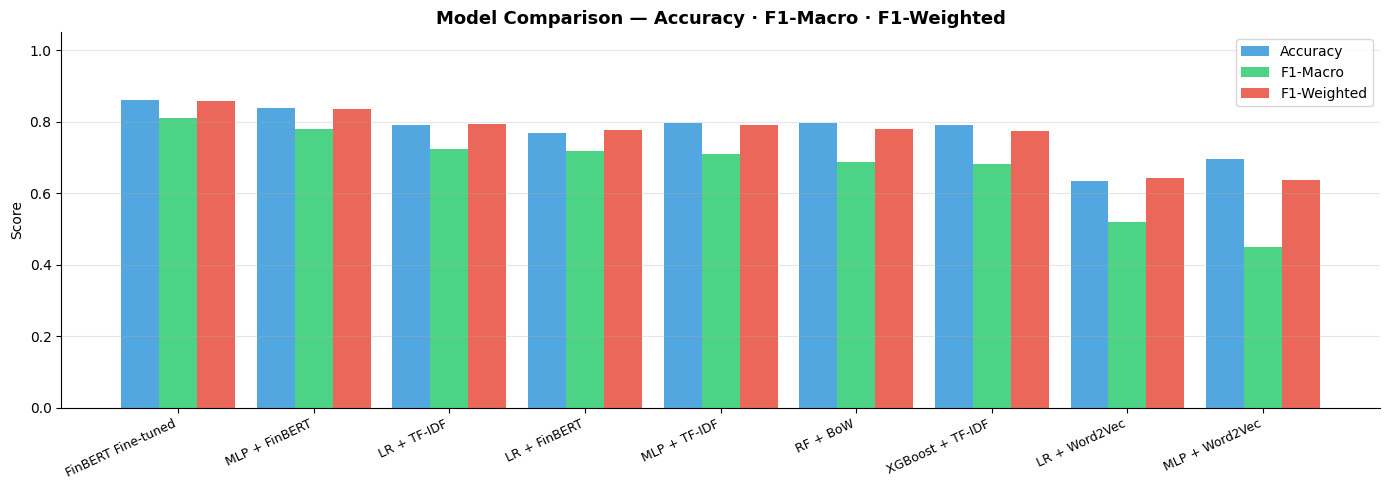

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
x     = range(len(results_df))
width = 0.28
ax.bar([i-width for i in x], results_df['accuracy'],    width, label='Accuracy',    color='#3498db', alpha=0.85)
ax.bar([i       for i in x], results_df['f1_macro'],    width, label='F1-Macro',    color='#2ecc71', alpha=0.85)
ax.bar([i+width for i in x], results_df['f1_weighted'], width, label='F1-Weighted', color='#e74c3c', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['model'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy · F1-Macro · F1-Weighted',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

[↑ Back to TOC](#toc)

<a class='anchor' id='8'></a>
---
## 8. Final Predictions on `test.csv`

Best model retrained on the **full training set**, then applied to `test.csv` → `pred_xx.csv`.

In [ ]:
# Retrain best classical model on full training data 
BEST_CLASSICAL = 'LR + TF-IDF'   # replace with whichever scored highest
best_pipeline  = classical_models[BEST_CLASSICAL]
best_pipeline.fit(X_classical, y)
print(f'{BEST_CLASSICAL} retrained on full training set.')

LR + TF-IDF retrained on full training set.


In [ ]:
df_test = pd.read_csv('test.csv')
print(f'Test set shape: {df_test.shape}')
print(df_test.head())

X_test_classical   = preprocess_classical(df_test['text'].tolist())
X_test_transformer = preprocess_transformer(df_test['text'].tolist())

Test set shape: (2388, 2)
   id                                               text
0   0  ETF assets to surge tenfold in 10 years to $50...
1   1  Here’s What Hedge Funds Think Evolution Petrol...
2   2  $PVH - Phillips-Van Heusen Q3 2020 Earnings Pr...
3   3  China is in the process of waiving retaliatory...
4   4  Highlight: “When growth is scarce, investors s...


Transformer preprocessing: 100%|██████████| 2388/2388 [00:00<00:00, 89395.03it/s]


In [ ]:
# Option A: best classical model
preds_classical = best_pipeline.predict(X_test_classical)

# Option B: fine-tuned FinBERT (recommended if fine-tuning was run)
# test_ds = Dataset.from_dict({'text': X_test_transformer})
# test_ds = test_ds.map(tokenize_fn, batched=True)
# preds_final = trainer.predict(test_ds).predictions.argmax(axis=1)

final_preds = preds_classical   # replace with preds_final if fine-tuning done
print(f'Prediction distribution: {pd.Series(final_preds).value_counts().sort_index().to_dict()}')

Prediction distribution: {0: 402, 1: 532, 2: 1454}


In [ ]:
submission = pd.DataFrame({'id': df_test['id'], 'label': final_preds})
submission.to_csv('pred_xx.csv', index=False)
print('Submission saved: pred_xx.csv')
print(submission.head(10))

Submission saved: pred_xx.csv
   id  label
0   0      2
1   1      2
2   2      2
3   3      2
4   4      2
5   5      0
6   6      2
7   7      2
8   8      1
9   9      2


[↑ Back to TOC](#toc)